
* Roland Angelo Roccaro: rolandangelo.roccaro@students.bfh.ch

#### Reading instruction:
Do search for "Comment" which is always the heading used at where we comment on the seen/inspected results.

# 1 Overview
Reminder : the Mandatory Practical Works are intended to be done in groups of max 3 students.
The goal is to apply the concepts seen in the lectures and practical sessions, and to document
your experimentation process and results in a report. The report should be clear, concise, and
well-structured, and should include all relevant details about your experiments, including the
hyperparameters you used, the results you obtained, and any insights or conclusions you can
draw from your experiments.
Clearly state the group members at the beginning of the report :
* Student 1 : [Name, Surname]
* Student 2 : [Name, Surname]
* Student 3 : [Name, Surname]

In [5]:
import sys
print(sys.executable)

C:\Users\rolan\PycharmProjects\pythonProject\venvDeLearn\Scripts\python.exe


In [6]:
import torch
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
from tqdm.notebook import tqdm
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from  datetime import datetime
from torchsummary import summary
import os
import pandas as pd
import wandb
print("wandb version:", wandb.__version__)
print("wandb file   :", wandb.__file__)
wandb.login()

%matplotlib inline

wandb version: 0.25.0
wandb file   : C:\Users\rolan\PycharmProjects\pythonProject\venvDeLearn\Lib\site-packages\wandb\__init__.py


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\rolan\_netrc.
wandb: Currently logged in as: rolandroccaro (rolandroccaro-berner-fachhochschule) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

# Downloading dataset
The data set is downloaded from:
https://drive.switch.ch/index.php/s/NTiYe8mamrgys3M
* Size 345.5MB
* Extracted .zip is interestingly the same size


# 2 Objectives

## Mandatory objectives

* a)
Start from simple CNN architectures and progressively increase their complexity to show the benefit of depth.

* b)
Show the importance of hyperparameter tuning.

* c)
Show models that overfit and underfit and explain the reasons for that.

* d)
Experiment with regularization techniques.

* e)
Experiment with different optimization algorithms (e.g., Adam, RMSprop) and compare their performance.

---

## Hint

Resizing the images e.g., 128x128 or 64x64 may be useful at the beginning of your investigations to perform quicker experimentations and sweep towards good settings.


=== PATH CHECK ===
DATA_ROOT exists: True data\icosimal_img_class_03\data_uniform_224_224_sets
TRAIN_DIR exists: True data\icosimal_img_class_03\data_uniform_224_224_sets\train
VAL_DIR exists: True data\icosimal_img_class_03\data_uniform_224_224_sets\validate

=== DATASET CHECK ===
Number of training samples   : 24000
Number of validation samples : 6000

=== CLASS CHECK ===
Classes found: ['cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'rabbit', 'sheep', 'squirrel', 'zebra']
Class to index mapping: {'cat': 0, 'chicken': 1, 'cow': 2, 'dog': 3, 'elephant': 4, 'horse': 5, 'rabbit': 6, 'sheep': 7, 'squirrel': 8, 'zebra': 9}
Number of classes: 10

=== SINGLE SAMPLE CHECK ===
Single image shape : torch.Size([3, 64, 64])
Single image dtype : torch.float32
Single label index : 0
Single label name  : cat
Pixel min / max    : 0.003921568859368563 1.0

=== BATCH CHECK ===
Batch image shape  : torch.Size([32, 3, 64, 64])
Batch label shape  : torch.Size([32])
Batch image dtype  : torch.float3

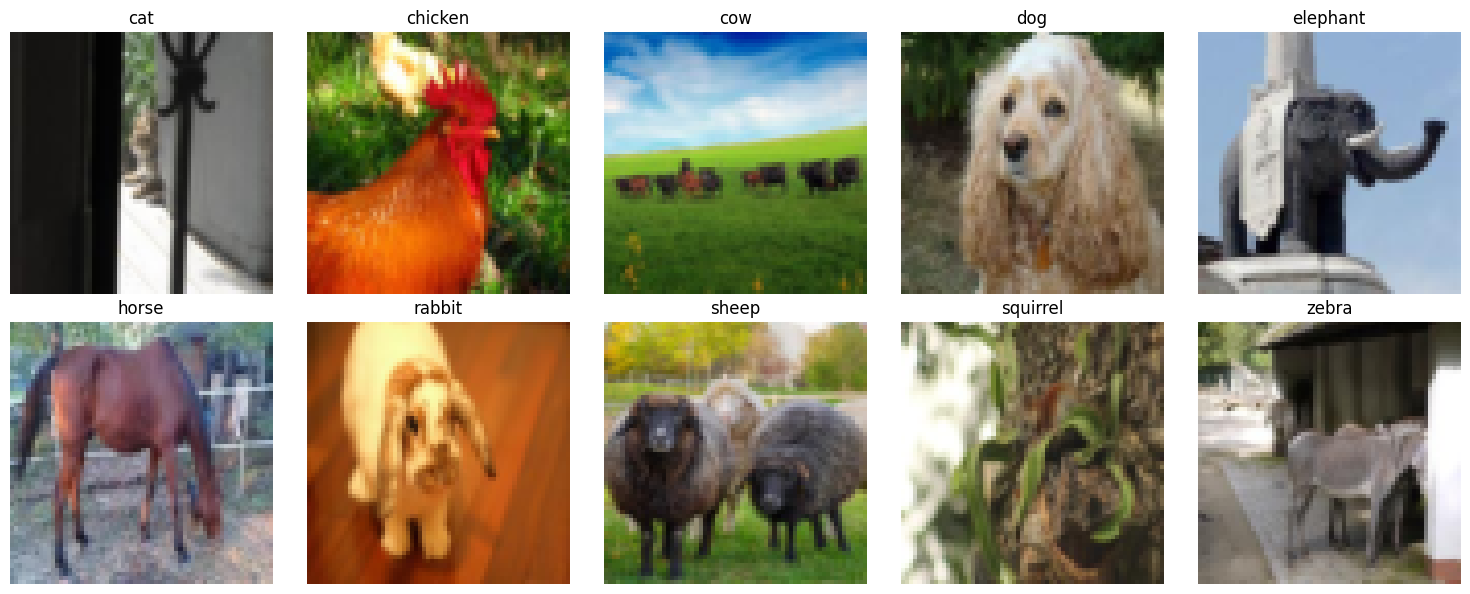

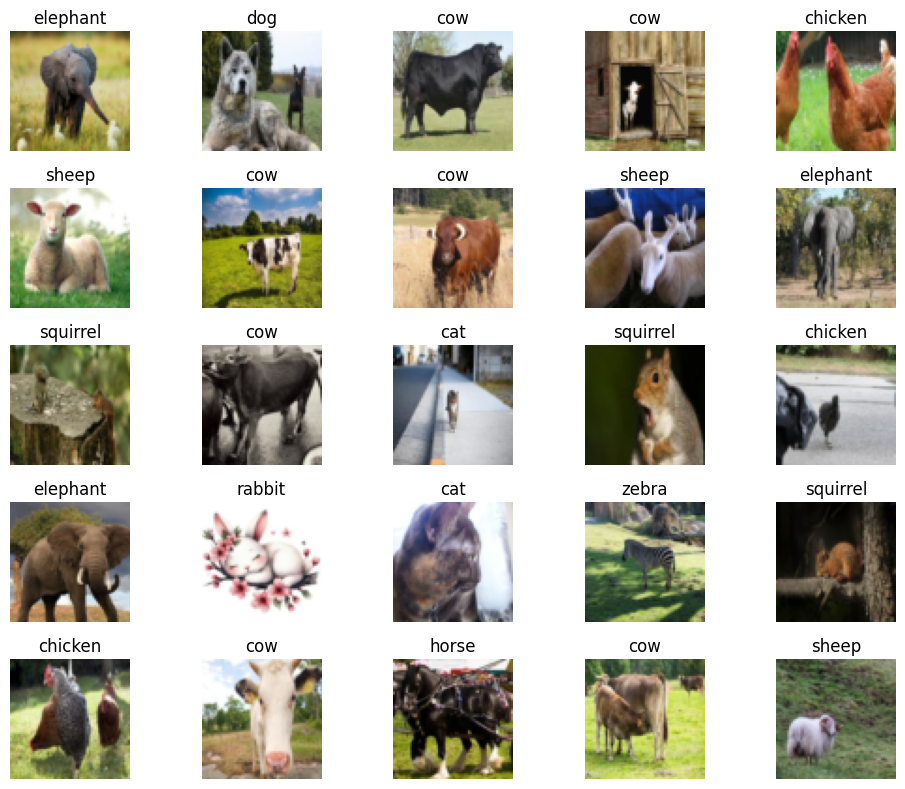

In [4]:
from pathlib import Path
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# =========================================================
# 1) Konfiguration
# =========================================================
DATA_ROOT = Path("data/icosimal_img_class_03/data_uniform_224_224_sets")

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "validate"

# Für erste CPU-Tests eher klein anfangen
IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0

device = torch.device("cpu")

# =========================================================
# 2) Vorprüfungen der Ordner
# =========================================================
print("=== PATH CHECK ===")
print("DATA_ROOT exists:", DATA_ROOT.exists(), DATA_ROOT)
print("TRAIN_DIR exists:", TRAIN_DIR.exists(), TRAIN_DIR)
print("VAL_DIR exists:", VAL_DIR.exists(), VAL_DIR)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT}")
if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"TRAIN_DIR not found: {TRAIN_DIR}")
if not VAL_DIR.exists():
    raise FileNotFoundError(f"VAL_DIR not found: {VAL_DIR}")

# =========================================================
# 3) Transforms
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),   # [0,255] -> float tensor in [0,1]
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

# =========================================================
# 4) Dataset laden
# =========================================================
train_data = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_data = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

# =========================================================
# 5) DataLoader
# =========================================================
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

# =========================================================
# 6) Übliche Prüfungen / Sanity Checks
# =========================================================
print("\n=== DATASET CHECK ===")
print("Number of training samples   :", len(train_data))
print("Number of validation samples :", len(val_data))

print("\n=== CLASS CHECK ===")
print("Classes found:", train_data.classes)
print("Class to index mapping:", train_data.class_to_idx)
print("Number of classes:", len(train_data.classes))

# einzelnes Sample prüfen
img0, label0 = train_data[0]

print("\n=== SINGLE SAMPLE CHECK ===")
print("Single image shape :", img0.shape)       # erwartet [C, H, W]
print("Single image dtype :", img0.dtype)
print("Single label index :", label0)
print("Single label name  :", train_data.classes[label0])
print("Pixel min / max    :", img0.min().item(), img0.max().item())

# Batch prüfen
batch_imgs, batch_labels = next(iter(train_loader))

print("\n=== BATCH CHECK ===")
print("Batch image shape  :", batch_imgs.shape)   # erwartet [B, C, H, W]
print("Batch label shape  :", batch_labels.shape) # erwartet [B]
print("Batch image dtype  :", batch_imgs.dtype)
print("Batch label dtype  :", batch_labels.dtype)
print("Batch pixel min/max:", batch_imgs.min().item(), batch_imgs.max().item())

# zusätzliche Plausibilitätsprüfung
assert img0.ndim == 3, f"Expected single image ndim=3, got {img0.ndim}"
assert batch_imgs.ndim == 4, f"Expected batch image ndim=4, got {batch_imgs.ndim}"
assert batch_labels.ndim == 1, f"Expected batch label ndim=1, got {batch_labels.ndim}"
assert img0.shape[0] in [1, 3], f"Unexpected channel count: {img0.shape[0]}"
assert len(train_data.classes) > 1, "Less than 2 classes found"
assert 0.0 <= img0.min() and img0.max() <= 1.0, "Tensor values are not in [0,1]"

print("\nAll basic sanity checks passed.")

# =========================================================
# 7) Klassen ausgeben
# =========================================================
print("\n=== CLASS LIST ===")
for idx, class_name in enumerate(train_data.classes):
    print(f"{idx:2d}: {class_name}")

# =========================================================
# 8) Von jeder Klasse genau ein Bild anzeigen
# =========================================================
def show_one_image_per_class(dataset):
    """
    Zeigt für jede Klasse ein Beispielbild.
    """
    classes = dataset.classes
    found = {class_name: None for class_name in classes}

    # suche erstes Bild pro Klasse
    for i in range(len(dataset)):
        img, label = dataset[i]
        class_name = classes[label]
        if found[class_name] is None:
            found[class_name] = (img, label)

        # stoppe wenn alle Klassen gefunden wurden
        if all(found[c] is not None for c in classes):
            break

    n_classes = len(classes)
    cols = min(5, n_classes)
    rows = (n_classes + cols - 1) // cols

    plt.figure(figsize=(3 * cols, 3 * rows))

    for idx, class_name in enumerate(classes, start=1):
        img, label = found[class_name]
        plt.subplot(rows, cols, idx)
        plt.imshow(img.permute(1, 2, 0))
        plt.title(f"{class_name}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_one_image_per_class(train_data)

# =========================================================
# 9) Zufällige Bilder anzeigen (ähnlich deinem CIFAR-Beispiel)
# =========================================================
def show_imgs(X, n=25):
    figure = plt.figure(figsize=(10, 8))
    cols, rows = 5, 5

    for i in range(1, min(n, cols * rows) + 1):
        sample_idx = torch.randint(len(X), size=(1,)).item()
        img, label = X[sample_idx]
        figure.add_subplot(rows, cols, i)
        plt.title(X.classes[label])
        plt.axis("off")
        plt.imshow(img.permute(1, 2, 0))

    plt.tight_layout()
    plt.show()

show_imgs(train_data)

The data set shows quite nice quality pictures however:
* it features a wide variety of different angles/colors and number of subjects on pictures
* which makes it questionable how good the results can be.
* Especially as some pictures depicts statues rather than animal (seen on one elephant example)

# Next
Start with a simple CNN
* use the hint of resizing the images to 64*64

In [8]:
from pathlib import Path
import json
from datetime import datetime


def append_experiment_history(
    filepath,
    model_class_name,
    model_description,
    config,
    history,
    training_time_sec
):
    """
    Appends one experiment run to a JSONL file.
    If the file does not exist, it is created.
    If it exists, the new run is appended at the end.

    Parameters
    ----------
    filepath : str or Path
        Path to the output .jsonl file
    model_class_name : str
        Mandatory model class name, e.g. "SmallCNN"
    model_description : str
        Mandatory human-readable description of the model
    config : dict
        Dictionary with experiment configuration / hyperparameters
    history : dict
        Must contain per-epoch metrics, e.g.
        {
            "train_loss": [...],
            "val_loss": [...],
            "train_acc": [...],
            "val_acc": [...]
        }
    training_time_sec : float
        Total training time in seconds
    """

    if not isinstance(model_class_name, str) or not model_class_name.strip():
        raise ValueError("model_class_name must be a non-empty string")

    if not isinstance(model_description, str) or not model_description.strip():
        raise ValueError("model_description must be a non-empty string")

    required_history_keys = ["train_loss", "val_loss", "train_acc", "val_acc"]
    for key in required_history_keys:
        if key not in history:
            raise ValueError(f"Missing required history key: {key}")

    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)

    record = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "model_class_name": model_class_name,
        "model_description": model_description,
        "config": config,
        "history": history,
        "summary": {
            "best_train_acc": max(history["train_acc"]) if history["train_acc"] else None,
            "final_train_acc": history["train_acc"][-1] if history["train_acc"] else None,
            "best_val_acc": max(history["val_acc"]) if history["val_acc"] else None,
            "final_val_acc": history["val_acc"][-1] if history["val_acc"] else None,
            "best_train_loss": min(history["train_loss"]) if history["train_loss"] else None,
            "final_train_loss": history["train_loss"][-1] if history["train_loss"] else None,
            "best_val_loss": min(history["val_loss"]) if history["val_loss"] else None,
            "final_val_loss": history["val_loss"][-1] if history["val_loss"] else None,
            "num_epochs_logged": len(history["train_loss"]),
            "training_time_sec": training_time_sec
        }
    }

    # append mode: existing file is preserved, new record always added at the end
    with open(filepath, "a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

    print(f"Experiment appended to: {filepath}")

    import json
from pathlib import Path
import matplotlib.pyplot as plt
from collections import defaultdict


def load_experiment_history(filepath):
    filepath = Path(filepath)
    records = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))

    return records


def plot_history_per_class(
    filepath,
    select="last",   # "first" oder "last"
    show_loss=True,
    show_accuracy=True
):
    """
    Plots training history for each model_class_name.

    Parameters
    ----------
    filepath : str
        Path to JSONL history file
    select : str
        "first" or "last" run per class
    show_loss : bool
    show_accuracy : bool
    """

    records = load_experiment_history(filepath)

    if len(records) == 0:
        print("No records found.")
        return

    # Gruppieren nach model_class_name
    grouped = defaultdict(list)
    for r in records:
        grouped[r["model_class_name"]].append(r)

    # Auswahl first/last pro Klasse
    selected_runs = []
    for class_name, runs in grouped.items():
        if select == "first":
            selected_runs.append(runs[0])
        elif select == "last":
            selected_runs.append(runs[-1])
        else:
            raise ValueError("select must be 'first' or 'last'")

    print(f"\nSelected {len(selected_runs)} runs (one per class, mode='{select}')")

    # =========================================================
    # LOSS PLOT
    # =========================================================
    if show_loss:
        plt.figure(figsize=(8, 5))

        for r in selected_runs:
            name = r["model_class_name"]
            desc = r["model_description"]

            train_loss = r["history"]["train_loss"]
            val_loss = r["history"]["val_loss"]

            plt.plot(train_loss, linestyle="--", label=f"{name} train")
            plt.plot(val_loss, linestyle="-", label=f"{name} val")

        plt.title(f"Loss per class ({select})")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

    # =========================================================
    # ACCURACY PLOT
    # =========================================================
    if show_accuracy:
        plt.figure(figsize=(8, 5))

        for r in selected_runs:
            name = r["model_class_name"]

            train_acc = r["history"]["train_acc"]
            val_acc = r["history"]["val_acc"]

            plt.plot(train_acc, linestyle="--", label=f"{name} train")
            plt.plot(val_acc, linestyle="-", label=f"{name} val")

        plt.title(f"Accuracy per class ({select})")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)
        plt.show()

# Extract by query string
* This code allows to query for specific experiments


In [9]:
import json
import re
from pathlib import Path
import matplotlib.pyplot as plt


def load_experiment_history(filepath):
    filepath = Path(filepath)
    records = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))

    return records


def filter_records_by_model_name(records, query, mode="startswith"):
    """
    Filtert Records anhand von model_class_name.

    mode:
        - "exact"      : exakter Match
        - "startswith" : beginnt mit query
        - "contains"   : enthält query
        - "regex"      : regulärer Ausdruck
    """
    filtered = []

    for r in records:
        model_name = r.get("model_class_name", "")

        if mode == "exact":
            ok = model_name == query
        elif mode == "startswith":
            ok = model_name.startswith(query)
        elif mode == "contains":
            ok = query in model_name
        elif mode == "regex":
            ok = re.search(query, model_name) is not None
        else:
            raise ValueError("mode must be one of: exact, startswith, contains, regex")

        if ok:
            filtered.append(r)

    return filtered


def plot_filtered_histories(
    filepath,
    model_name_query,
    mode="startswith",
    show_loss=True,
    show_accuracy=True,
    print_matches=True
):
    """
    Lädt alle Runs aus der JSONL-Datei, filtert sie nach model_class_name
    und plottet Train/Validation Loss und Accuracy.

    Beispiel:
        mode="startswith", model_name_query="SmallCNN"
        -> matched z.B. SmallCNN, SmallCNN_BATCHNORM, SmallCNN_OPT, ...
    """
    records = load_experiment_history(filepath)
    filtered = filter_records_by_model_name(records, model_name_query, mode=mode)

    if len(filtered) == 0:
        print("Keine passenden Records gefunden.")
        return

    if print_matches:
        print(f"Gefundene Runs: {len(filtered)}")
        for i, r in enumerate(filtered, start=1):
            print(f"{i:2d}. {r.get('model_class_name')} | {r.get('model_description', '')}")

    # -------------------------
    # LOSS
    # -------------------------
    if show_loss:
        plt.figure(figsize=(10, 6))

        for i, r in enumerate(filtered, start=1):
            history = r["history"]
            model_name = r["model_class_name"]

            train_loss = history["train_loss"]
            val_loss = history["val_loss"]

            plt.plot(train_loss, linestyle="--", label=f"{model_name} train [{i}]")
            plt.plot(val_loss, linestyle="-", label=f"{model_name} val [{i}]")

        plt.title(f"Loss comparison | model_class_name {mode} '{model_name_query}'")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

    # -------------------------
    # ACCURACY
    # -------------------------
    if show_accuracy:
        plt.figure(figsize=(10, 6))

        for i, r in enumerate(filtered, start=1):
            history = r["history"]
            model_name = r["model_class_name"]

            train_acc = history["train_acc"]
            val_acc = history["val_acc"]

            plt.plot(train_acc, linestyle="--", label=f"{model_name} train [{i}]")
            plt.plot(val_acc, linestyle="-", label=f"{model_name} val [{i}]")

        plt.title(f"Accuracy comparison | model_class_name {mode} '{model_name_query}'")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)
        plt.show()

# Calling the visualisation of stored experiment history
* Graphs for every Small CNN
*

Gefundene Runs: 5
 1. SmallCNN_AUG | Data augmentation study with setting aug_1_very_light
 2. SmallCNN_AUG | Data augmentation study with setting aug_2_light
 3. SmallCNN_AUG | Data augmentation study with setting aug_3_medium
 4. SmallCNN_AUG | Data augmentation study with setting aug_4_strong
 5. SmallCNN_AUG | Data augmentation study with setting aug_5_very_strong


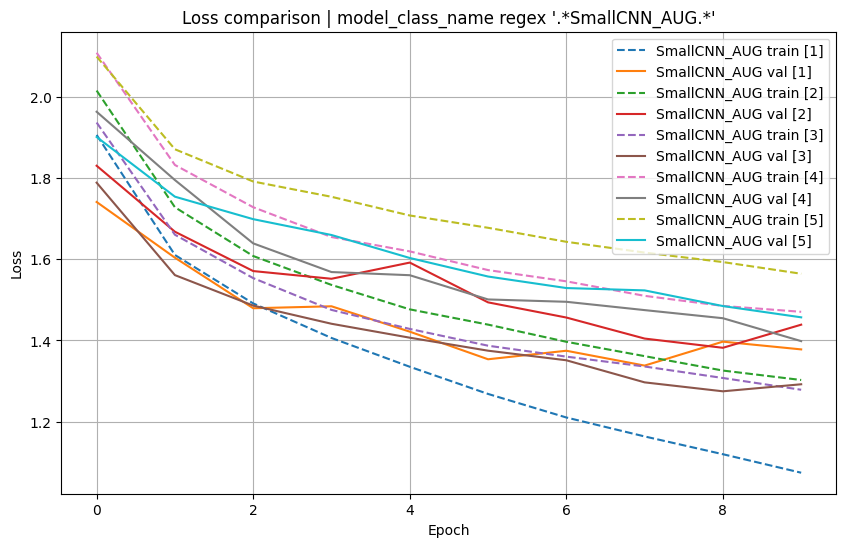

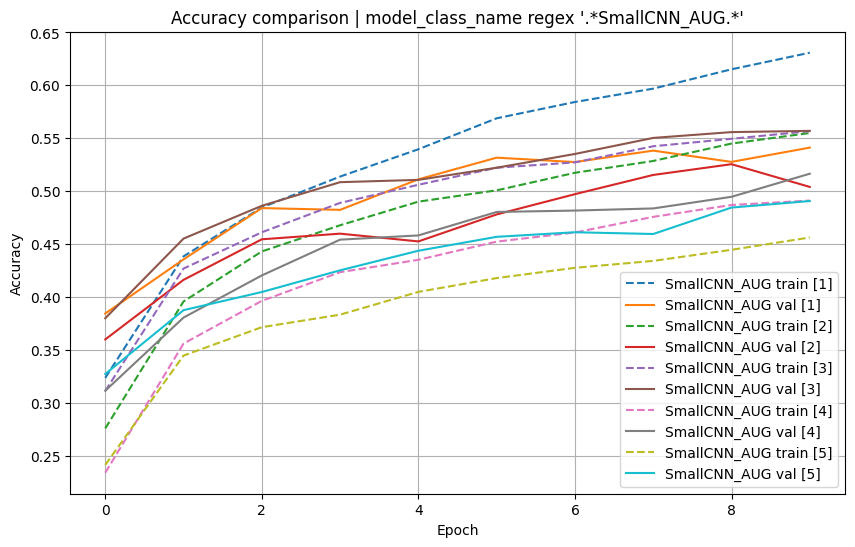

In [29]:
plot_filtered_histories(
    filepath="results/experiment_history.jsonl",
    model_name_query=r".*SmallCNN_AUG.*",
    mode="regex"
)

# Simple CNN
First simple cnn, only 1 layer


In [6]:
import torch
import torch.nn as nn
import time
import json
from pathlib import Path
from datetime import datetime

import wandb

run = wandb.init(
    project="deep-learning-cnn-assignment",
    name="TinyCNN_Laptop_CPU",
)
print("W&B run started:", run.name)
wandb.log({"test_metric": 1.0})

# =========================================================
# 1) Hilfsfunktionen (Training + Eval)
# =========================================================
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)

        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    return running_loss / running_total, running_correct / running_total


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)

        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    return running_loss / running_total, running_correct / running_total


def run_training(model, train_loader, val_loader, criterion, optimizer, device, num_epochs):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    total_time = time.time() - start_time
    return history, total_time


# =========================================================
# 2) JSONL Speicherung
# =========================================================
def append_experiment_history(filepath, model_class_name, model_description, config, history, training_time_sec):

    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)

    record = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "model_class_name": model_class_name,
        "model_description": model_description,
        "config": config,
        "history": history,
        "summary": {
            "best_val_acc": max(history["val_acc"]),
            "final_val_acc": history["val_acc"][-1],
            "best_val_loss": min(history["val_loss"]),
            "final_val_loss": history["val_loss"][-1],
            "training_time_sec": training_time_sec
        }
    }

    with open(filepath, "a", encoding="utf-8") as f:
        f.write(json.dumps(record) + "\n")

    print(f"Saved to {filepath}")


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# =========================================================
# 3) TinyCNN (1 Layer)
# =========================================================
class TinyCNN(nn.Module):
    """
    Minimal CNN baseline (1 Conv Layer)
    """

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 32 * 32, num_classes)  # funktioniert bei IMAGE_SIZE = 64
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# =========================================================
# 4) Setup
# =========================================================
device = torch.device("cpu")

num_classes = len(train_data.classes)

model = TinyCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# =========================================================
# 5) Training (10 Epochen)
# =========================================================
history, total_time = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=10
)


# =========================================================
# 6) Config speichern
# =========================================================
experiment_config = {
    "model_name": "TinyCNN",
    "image_size": 64,
    "batch_size": 32,
    "num_epochs": 10,
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "conv_layers": 1,
    "filters": [8],
    "kernel_size": 3,
    "pooling": "MaxPool2d(2)",
    "dropout": 0.0,
    "batch_norm": False,
    "device": "cpu",
    "num_trainable_parameters": count_trainable_parameters(model),
    "num_classes": num_classes,
    "class_names": train_data.classes
}


# =========================================================
# 7) Speichern
# =========================================================
append_experiment_history(
    filepath="results/experiment_history.jsonl",
    model_class_name="TinyCNN",
    model_description="Single convolution layer baseline CNN for comparison",
    config=experiment_config,
    history=history,
    training_time_sec=total_time
)

W&B run started: TinyCNN_Laptop_CPU
Epoch [1/10] | train_loss=2.0314, train_acc=0.2821 | val_loss=1.8652, val_acc=0.3607
Epoch [2/10] | train_loss=1.7647, train_acc=0.3952 | val_loss=1.7806, val_acc=0.3763
Epoch [3/10] | train_loss=1.6385, train_acc=0.4441 | val_loss=1.7736, val_acc=0.3907
Epoch [4/10] | train_loss=1.5507, train_acc=0.4773 | val_loss=1.7147, val_acc=0.4153
Epoch [5/10] | train_loss=1.4757, train_acc=0.5060 | val_loss=1.7325, val_acc=0.4168
Epoch [6/10] | train_loss=1.4110, train_acc=0.5264 | val_loss=1.7437, val_acc=0.4088
Epoch [7/10] | train_loss=1.3633, train_acc=0.5466 | val_loss=1.7386, val_acc=0.4170
Epoch [8/10] | train_loss=1.3110, train_acc=0.5635 | val_loss=1.7978, val_acc=0.4050
Epoch [9/10] | train_loss=1.2710, train_acc=0.5763 | val_loss=1.7965, val_acc=0.4093
Epoch [10/10] | train_loss=1.2306, train_acc=0.5921 | val_loss=1.7998, val_acc=0.4078
Saved to results\experiment_history.jsonl


# Report
* After 2 epochs, definitely after the third. the gain in validation accuracy capped
* The train accuracy was still slowly rising but shows a big gap 0.6087 to 0.4045 and high overfitting

In [7]:
import torch
import torch.nn as nn

# =========================================================
# 1) Modell: SmallCNN (2 Conv Layers)
# =========================================================
import wandb
run = wandb.init(
    project="deep-learning-cnn-assignment",
    name="SmallCNN_Laptop_CPU",
)
print("W&B run started:", run.name)

class SmallCNN(nn.Module):
    """
    CNN with 2 convolution layers
    """

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 → 32

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 32 → 16
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# =========================================================
# 2) Setup
# =========================================================
device = torch.device("cpu")

num_classes = len(train_data.classes)

model = SmallCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


# =========================================================
# 3) Training
# =========================================================
history, total_time = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=10
)


# =========================================================
# 4) Config
# =========================================================
experiment_config = {
    "model_name": "SmallCNN",
    "image_size": 64,
    "batch_size": 32,
    "num_epochs": 10,
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "conv_layers": 2,
    "filters": [16, 32],
    "kernel_sizes": [3, 3],
    "pooling": "MaxPool2d(2)",
    "dense_units": [64],
    "dropout": 0.0,
    "batch_norm": False,
    "device": "cpu",
    "num_trainable_parameters": count_trainable_parameters(model),
    "num_classes": num_classes,
    "class_names": train_data.classes
}


# =========================================================
# 5) Speichern
# =========================================================
append_experiment_history(
    filepath="results/experiment_history.jsonl",
    model_class_name="SmallCNN",
    model_description="Two-layer CNN with increasing filters (16→32) and a small dense head",
    config=experiment_config,
    history=history,
    training_time_sec=total_time
)

test_metric,▁
test_metric,1


W&B run started: SmallCNN_Laptop_CPU
Epoch [1/10] | train_loss=1.9509, train_acc=0.3044 | val_loss=1.6750, val_acc=0.4087
Epoch [2/10] | train_loss=1.5859, train_acc=0.4491 | val_loss=1.6043, val_acc=0.4410
Epoch [3/10] | train_loss=1.4355, train_acc=0.5042 | val_loss=1.4607, val_acc=0.4885
Epoch [4/10] | train_loss=1.3170, train_acc=0.5473 | val_loss=1.4283, val_acc=0.5038
Epoch [5/10] | train_loss=1.2224, train_acc=0.5790 | val_loss=1.4306, val_acc=0.5073
Epoch [6/10] | train_loss=1.1210, train_acc=0.6172 | val_loss=1.4508, val_acc=0.5063
Epoch [7/10] | train_loss=1.0242, train_acc=0.6497 | val_loss=1.4979, val_acc=0.5013
Epoch [8/10] | train_loss=0.9301, train_acc=0.6800 | val_loss=1.6298, val_acc=0.4852
Epoch [9/10] | train_loss=0.8318, train_acc=0.7167 | val_loss=1.5835, val_acc=0.5130
Epoch [10/10] | train_loss=0.7383, train_acc=0.7477 | val_loss=1.6506, val_acc=0.5125
Saved to results\experiment_history.jsonl


# Report
* The 2 layer cnn performs better after 5 epochs, the validation accuracy reached 0.4917 . which was the top value. After this the train accuracy raised further while validationa accuracy was capped
* Thus the model started to overfit at this stage
* biger depth increased the resulting validation accuracy by 7 to 8 percent

In [ ]:
import torch
import torch.nn as nn
import wandb

run = wandb.init(
    project="deep-learning-cnn-assignment",
    name="MediumCNN_Laptop_CPU",
)
print("W&B run started:", run.name)

class MediumCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 -> 16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 16 -> 8
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


device = torch.device("cpu")

num_classes = len(train_data.classes)

model = MediumCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

history, total_time = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=10
)

experiment_config = {
    "model_name": "MediumCNN",
    "image_size": 64,
    "batch_size": 32,
    "num_epochs": 10,
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "conv_layers": 3,
    "filters": [16, 32, 64],
    "kernel_sizes": [3, 3, 3],
    "pooling": "MaxPool2d(2)",
    "dense_units": [64],
    "dropout": 0.0,
    "batch_norm": False,
    "device": "cpu",
    "num_trainable_parameters": count_trainable_parameters(model),
    "num_classes": num_classes,
    "class_names": train_data.classes
}

append_experiment_history(
    filepath="results/experiment_history.jsonl",
    model_class_name="MediumCNN",
    model_description="Three-layer CNN with filters 16→32→64 and a small dense head",
    config=experiment_config,
    history=history,
    training_time_sec=total_time
)

W&B run started: MediumCNN_Laptop_CPU
Epoch [1/10] | train_loss=1.9672, train_acc=0.2926 | val_loss=1.7681, val_acc=0.3778
Epoch [2/10] | train_loss=1.5960, train_acc=0.4437 | val_loss=1.5121, val_acc=0.4690
Epoch [3/10] | train_loss=1.4441, train_acc=0.5014 | val_loss=1.4429, val_acc=0.4958
Epoch [4/10] | train_loss=1.3462, train_acc=0.5328 | val_loss=1.4135, val_acc=0.5165


# Report
* Now with 3 layers, the validation acuracy is now capping at Epoch 7
* Validation accuracy gut up to 0.5498 and train_acc reached 0.5997 at that epoch
* After this epoch the train acc is still rising while the validation accuracy is capped


In [33]:
import torch
import torch.nn as nn

# =========================================================
# 1) Modell: DeepCNN (5 Conv Layers)
# =========================================================

run = wandb.init(
    project="deep-learning-cnn-assignment",
    name="DeepCNN_Laptop_CPU",
)
print("W&B run started:", run.name)


class DeepCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 -> 16

            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 16 -> 8

            # Block 4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 8 -> 4

            # Block 5
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 4 -> 2
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 2 * 2, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# =========================================================
# 2) Setup
# =========================================================
device = torch.device("cpu")

num_classes = len(train_data.classes)

model = DeepCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


# =========================================================
# 3) Training
# =========================================================
history, total_time = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=10
)


# =========================================================
# 4) Config
# =========================================================
experiment_config = {
    "model_name": "DeepCNN",
    "image_size": 64,
    "batch_size": 32,
    "num_epochs": 10,
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "conv_layers": 5,
    "filters": [16, 32, 64, 128, 128],
    "kernel_sizes": [3, 3, 3, 3, 3],
    "pooling": "MaxPool2d(2)",
    "dense_units": [64],
    "dropout": 0.0,
    "batch_norm": False,
    "device": "cpu",
    "num_trainable_parameters": count_trainable_parameters(model),
    "num_classes": num_classes,
    "class_names": train_data.classes
}


# =========================================================
# 5) Speichern
# =========================================================
append_experiment_history(
    filepath="results/experiment_history.jsonl",
    model_class_name="DeepCNN",
    model_description="Five-layer CNN with increasing filters (16→32→64→128→128)",
    config=experiment_config,
    history=history,
    training_time_sec=total_time
)

Epoch [1/10] | train_loss=2.1187, train_acc=0.2172 | val_loss=1.8634, val_acc=0.3290
Epoch [2/10] | train_loss=1.6938, train_acc=0.4030 | val_loss=1.5900, val_acc=0.4338
Epoch [3/10] | train_loss=1.5014, train_acc=0.4721 | val_loss=1.4204, val_acc=0.4947
Epoch [4/10] | train_loss=1.3749, train_acc=0.5160 | val_loss=1.4629, val_acc=0.4883
Epoch [5/10] | train_loss=1.2792, train_acc=0.5497 | val_loss=1.2907, val_acc=0.5417
Epoch [6/10] | train_loss=1.1889, train_acc=0.5860 | val_loss=1.2953, val_acc=0.5405
Epoch [7/10] | train_loss=1.0944, train_acc=0.6182 | val_loss=1.2043, val_acc=0.5733
Epoch [8/10] | train_loss=1.0127, train_acc=0.6481 | val_loss=1.2166, val_acc=0.5853
Epoch [9/10] | train_loss=0.9331, train_acc=0.6738 | val_loss=1.2146, val_acc=0.5798
Epoch [10/10] | train_loss=0.8522, train_acc=0.7017 | val_loss=1.2284, val_acc=0.5900
Saved to results\experiment_history.jsonl


# Report
* Also with 5 layers the accuracy has further improved
* also the validation accuracy got even better...
* However so does the training time, now up to 34m 13s
* Also here we can see that the accuracy of train and validation show overfitting starting at Epoch 7 where the accuracies are getting further apart from each other
* The print show this

## Summary of Task a)

Todo... write this into english and check for missed stuff
Gut, ich will nun zusammenfassen was in a) gesehen wurde. was muss ich hier als learning g nennen ? ich sehe da z,b, das die accuracy pro layer steigt, aber ohne zusätzliche massnahmen wurde es bei 5 layer dann schlechter... also die verbesserungen wurden nicht mehr deutlich mehr. ausserdem muss ich anmerken das es natürlich länger dauert... ich habe die layers alle auf einem CPU trainiert... und suche nun nach den schritten die ich brauche um eine entwicklungsumgebung auf meinem spieler laptop zu installieren. ...  was noch ?


In [34]:
import torch
import torch.nn as nn
run = wandb.init(
    project="deep-learning-cnn-assignment",
    name="LearningRatesCNN_Laptop_CPU",
)
print("W&B run started:", run.name)

# =========================================================
# 2) Setup
# =========================================================
device = torch.device("cpu")
num_classes = len(train_data.classes)

learning_rates = [1e-2, 1e-3, 1e-4, 5e-4]  # inkl. Standard (1e-3)

results = []

# =========================================================
# 3) Mehrere Trainingsläufe
# =========================================================
for lr in learning_rates:

    print("\n" + "="*60)
    print(f"Training with learning_rate = {lr}")
    print("="*60)

    model = SmallCNN(num_classes=num_classes).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    history, total_time = run_training(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=10
    )

    # =========================================================
    # Config
    # =========================================================
    experiment_config = {
        "model_name": "SmallCNN_LR_Study",
        "image_size": 64,
        "batch_size": 32,
        "num_epochs": 10,
        "optimizer": "Adam",
        "learning_rate": lr,
        "conv_layers": 2,
        "filters": [16, 32],
        "kernel_sizes": [3, 3],
        "pooling": "MaxPool2d(2)",
        "dense_units": [64],
        "dropout": 0.0,
        "batch_norm": False,
        "device": "cpu",
        "num_trainable_parameters": count_trainable_parameters(model),
        "num_classes": num_classes,
        "class_names": train_data.classes
    }

    # =========================================================
    # Speichern
    # =========================================================
    append_experiment_history(
        filepath="results/experiment_history.jsonl",
        model_class_name="SmallCNN_LR",
        model_description=f"Learning rate study with lr={lr}",
        config=experiment_config,
        history=history,
        training_time_sec=total_time
    )

    results.append({
        "lr": lr,
        "best_val_acc": max(history["val_acc"]),
        "final_val_acc": history["val_acc"][-1],
        "best_val_loss": min(history["val_loss"]),
        "time": total_time
    })


# =========================================================
# 4) Ergebnisse sortieren
# =========================================================
results = sorted(results, key=lambda x: x["best_val_acc"], reverse=True)

print("\n=== Learning Rate Results ===")
for r in results:
    print(
        f"lr={r['lr']} | "
        f"best_val_acc={r['best_val_acc']:.4f} | "
        f"final_val_acc={r['final_val_acc']:.4f} | "
        f"loss={r['best_val_loss']:.4f} | "
        f"time={r['time']:.1f}s"
    )


Training with learning_rate = 0.01
Epoch [1/10] | train_loss=2.3077, train_acc=0.1000 | val_loss=2.3031, val_acc=0.1000
Epoch [2/10] | train_loss=2.3041, train_acc=0.0996 | val_loss=2.3036, val_acc=0.1000
Epoch [3/10] | train_loss=2.3040, train_acc=0.1000 | val_loss=2.3042, val_acc=0.1000
Epoch [4/10] | train_loss=2.3041, train_acc=0.0989 | val_loss=2.3035, val_acc=0.1000
Epoch [5/10] | train_loss=2.3038, train_acc=0.1016 | val_loss=2.3034, val_acc=0.1000
Epoch [6/10] | train_loss=2.3038, train_acc=0.0996 | val_loss=2.3042, val_acc=0.1000
Epoch [7/10] | train_loss=2.3044, train_acc=0.0993 | val_loss=2.3032, val_acc=0.1000
Epoch [8/10] | train_loss=2.3039, train_acc=0.0976 | val_loss=2.3037, val_acc=0.1000
Epoch [9/10] | train_loss=2.3038, train_acc=0.1020 | val_loss=2.3033, val_acc=0.1000
Epoch [10/10] | train_loss=2.3039, train_acc=0.1008 | val_loss=2.3039, val_acc=0.1000
Saved to results\experiment_history.jsonl

Training with learning_rate = 0.001
Epoch [1/10] | train_loss=1.9668, 

# Report
Blabla...
* 0.01 , unbrauchbar accuracy um 0.01 ... lernt garnichts
* andere.... alle ziemlich gleich...
* daher noch 0.00001 und 0.000001

In [35]:
import torch
import torch.nn as nn
run = wandb.init(
    project="deep-learning-cnn-assignment",
    name="LearningRatesMoreCNN_Laptop_CPU",
)
print("W&B run started:", run.name)

# =========================================================
# 2) Setup
# =========================================================
device = torch.device("cpu")
num_classes = len(train_data.classes)

learning_rates = [1e-5, 1e-6]  # inkl. Standard (1e-3)

results = []

# =========================================================
# 3) Mehrere Trainingsläufe
# =========================================================
for lr in learning_rates:

    print("\n" + "="*60)
    print(f"Training with learning_rate = {lr}")
    print("="*60)

    model = SmallCNN(num_classes=num_classes).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    history, total_time = run_training(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=10
    )

    # =========================================================
    # Config
    # =========================================================
    experiment_config = {
        "model_name": "SmallCNN_LR_Study",
        "image_size": 64,
        "batch_size": 32,
        "num_epochs": 10,
        "optimizer": "Adam",
        "learning_rate": lr,
        "conv_layers": 2,
        "filters": [16, 32],
        "kernel_sizes": [3, 3],
        "pooling": "MaxPool2d(2)",
        "dense_units": [64],
        "dropout": 0.0,
        "batch_norm": False,
        "device": "cpu",
        "num_trainable_parameters": count_trainable_parameters(model),
        "num_classes": num_classes,
        "class_names": train_data.classes
    }

    # =========================================================
    # Speichern
    # =========================================================
    append_experiment_history(
        filepath="results/experiment_history.jsonl",
        model_class_name="SmallCNN_LR",
        model_description=f"Learning rate study with lr={lr}",
        config=experiment_config,
        history=history,
        training_time_sec=total_time
    )

    results.append({
        "lr": lr,
        "best_val_acc": max(history["val_acc"]),
        "final_val_acc": history["val_acc"][-1],
        "best_val_loss": min(history["val_loss"]),
        "time": total_time
    })


# =========================================================
# 4) Ergebnisse sortieren
# =========================================================
results = sorted(results, key=lambda x: x["best_val_acc"], reverse=True)

print("\n=== Learning Rate Results ===")
for r in results:
    print(
        f"lr={r['lr']} | "
        f"best_val_acc={r['best_val_acc']:.4f} | "
        f"final_val_acc={r['final_val_acc']:.4f} | "
        f"loss={r['best_val_loss']:.4f} | "
        f"time={r['time']:.1f}s"
    )


Training with learning_rate = 1e-05
Epoch [1/10] | train_loss=2.2927, train_acc=0.1299 | val_loss=2.2730, val_acc=0.1833
Epoch [2/10] | train_loss=2.2398, train_acc=0.2117 | val_loss=2.2050, val_acc=0.2278
Epoch [3/10] | train_loss=2.1768, train_acc=0.2457 | val_loss=2.1527, val_acc=0.2518
Epoch [4/10] | train_loss=2.1311, train_acc=0.2620 | val_loss=2.1171, val_acc=0.2608
Epoch [5/10] | train_loss=2.0995, train_acc=0.2739 | val_loss=2.0910, val_acc=0.2770
Epoch [6/10] | train_loss=2.0735, train_acc=0.2873 | val_loss=2.0670, val_acc=0.2840
Epoch [7/10] | train_loss=2.0498, train_acc=0.2944 | val_loss=2.0469, val_acc=0.2890
Epoch [8/10] | train_loss=2.0288, train_acc=0.3048 | val_loss=2.0271, val_acc=0.2933
Epoch [9/10] | train_loss=2.0096, train_acc=0.3127 | val_loss=2.0103, val_acc=0.3023
Epoch [10/10] | train_loss=1.9917, train_acc=0.3188 | val_loss=1.9947, val_acc=0.3138
Saved to results\experiment_history.jsonl

Training with learning_rate = 1e-06
Epoch [1/10] | train_loss=2.3048,

Bla... das zeigt und nun die performance das...
b) Show the importance of hyperparameter tuning.
c) Show models that overfit and underfit and explain the reasons for that.

* zeige den plot
* Unterfitting und overfitting....
* Mache grössere modelle... oder... einfach 20 epochen
* ich habe bereits unterfittende modelle (klein)
* Overfitting tun alle...
* over... learns the train set by hearth... does not generalise well
* under... learns not enough of the dataset.. nur oberflächlich...

In [6]:
import torch
import torch.nn as nn
run = wandb.init(
    project="deep-learning-cnn-assignment",
    name="OptimizersCNN_Laptop_CPU",
)
print("W&B run started:", run.name)


# =========================================================
# 1) Modell: SmallCNN (2 Layer)
# =========================================================
class SmallCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 32 -> 16
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# =========================================================
# 2) Setup
# =========================================================
device = torch.device("cpu")
num_classes = len(train_data.classes)

learning_rate = 1e-3
optimizers_to_test = ["Adam", "RMSprop"]

results = []

# =========================================================
# 3) Optimizer-Studie
# =========================================================
for optimizer_name in optimizers_to_test:

    print("\n" + "=" * 60)
    print(f"Training with optimizer = {optimizer_name}")
    print("=" * 60)

    model = SmallCNN(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )
    elif optimizer_name == "RMSprop":
        optimizer = torch.optim.RMSprop(
            model.parameters(),
            lr=learning_rate
        )
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    history, total_time = run_training(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=10
    )

    # =========================================================
    # Config
    # =========================================================
    experiment_config = {
        "model_name": "SmallCNN_Optimizer_Study",
        "image_size": 64,
        "batch_size": 32,
        "num_epochs": 10,
        "optimizer": optimizer_name,
        "learning_rate": learning_rate,
        "conv_layers": 2,
        "filters": [16, 32],
        "kernel_sizes": [3, 3],
        "pooling": "MaxPool2d(2)",
        "dense_units": [64],
        "dropout": 0.0,
        "batch_norm": False,
        "device": "cpu",
        "num_trainable_parameters": count_trainable_parameters(model),
        "num_classes": num_classes,
        "class_names": train_data.classes
    }

    # =========================================================
    # Speichern
    # =========================================================
    append_experiment_history(
        filepath="results/experiment_history.jsonl",
        model_class_name="SmallCNN_OPT",
        model_description=f"Optimizer comparison using {optimizer_name} with lr={learning_rate}",
        config=experiment_config,
        history=history,
        training_time_sec=total_time
    )

    results.append({
        "optimizer": optimizer_name,
        "best_val_acc": max(history["val_acc"]),
        "final_val_acc": history["val_acc"][-1],
        "best_val_loss": min(history["val_loss"]),
        "final_val_loss": history["val_loss"][-1],
        "training_time_sec": total_time
    })


# =========================================================
# 4) Ergebnisse ausgeben
# =========================================================
results = sorted(results, key=lambda x: x["best_val_acc"], reverse=True)

print("\n=== Optimizer Comparison Results ===")
for r in results:
    print(
        f"optimizer={r['optimizer']} | "
        f"best_val_acc={r['best_val_acc']:.4f} | "
        f"final_val_acc={r['final_val_acc']:.4f} | "
        f"best_val_loss={r['best_val_loss']:.4f} | "
        f"final_val_loss={r['final_val_loss']:.4f} | "
        f"time={r['training_time_sec']:.1f}s"
    )


Training with optimizer = Adam
Epoch [1/10] | train_loss=1.9517, train_acc=0.3102 | val_loss=1.6951, val_acc=0.4042
Epoch [2/10] | train_loss=1.5943, train_acc=0.4518 | val_loss=1.5449, val_acc=0.4605
Epoch [3/10] | train_loss=1.4455, train_acc=0.5032 | val_loss=1.4945, val_acc=0.4795
Epoch [4/10] | train_loss=1.3188, train_acc=0.5455 | val_loss=1.4986, val_acc=0.4785
Epoch [5/10] | train_loss=1.2221, train_acc=0.5798 | val_loss=1.4243, val_acc=0.5105
Epoch [6/10] | train_loss=1.1191, train_acc=0.6155 | val_loss=1.4793, val_acc=0.5062
Epoch [7/10] | train_loss=1.0287, train_acc=0.6465 | val_loss=1.5106, val_acc=0.5075
Epoch [8/10] | train_loss=0.9263, train_acc=0.6841 | val_loss=1.5439, val_acc=0.5082
Epoch [9/10] | train_loss=0.8445, train_acc=0.7109 | val_loss=1.5684, val_acc=0.5083
Epoch [10/10] | train_loss=0.7497, train_acc=0.7444 | val_loss=1.6442, val_acc=0.5117
Saved to results\experiment_history.jsonl

Training with optimizer = RMSprop
Epoch [1/10] | train_loss=1.9409, train_

# Result
this is my code for optimisers..
adam... rmsprop
Comparing their performance...
* Note, i should also run different settings for both rms and adam

In [8]:
import torch
import torch.nn as nn

# =========================================================
# 1) Modell ohne Regularisierung (für Weight Decay Studie)
# =========================================================
class SmallCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 32 -> 16
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# =========================================================
# 2) Modell mit Dropout
# =========================================================
class SmallCNNDropout(nn.Module):
    def __init__(self, num_classes, dropout_p=0.2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(dropout_p),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(dropout_p)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# =========================================================
# 3) Setup
# =========================================================
device = torch.device("cpu")
num_classes = len(train_data.classes)

# Wir halten Architektur / Bildgröße / Epochen etc. konstant
learning_rate = 1e-3
num_epochs = 10

# Dropout-Studie:
# mittel = 0.2 ist an die Folien angelehnt
dropout_values = [0.1, 0.2, 0.5]

# Weight Decay Studie:
# Werte sind sinnvolle Vergleichswerte für L2-Regularisierung
weight_decay_values = [1e-5, 1e-4, 1e-3]

dropout_results = []
weight_decay_results = []

# =========================================================
# 4) Dropout-Studie
# =========================================================
for dropout_p in dropout_values:
    print("\n" + "=" * 70)
    print(f"Dropout study: dropout_p = {dropout_p}")
    print("=" * 70)

    model = SmallCNNDropout(num_classes=num_classes, dropout_p=dropout_p).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history, total_time = run_training(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs
    )

    experiment_config = {
        "model_name": "SmallCNN_Dropout_Study",
        "image_size": 64,
        "batch_size": 32,
        "num_epochs": num_epochs,
        "optimizer": "Adam",
        "learning_rate": learning_rate,
        "conv_layers": 2,
        "filters": [16, 32],
        "kernel_sizes": [3, 3],
        "pooling": "MaxPool2d(2)",
        "dense_units": [64],
        "dropout": dropout_p,
        "batch_norm": False,
        "weight_decay": 0.0,
        "device": "cpu",
        "num_trainable_parameters": count_trainable_parameters(model),
        "num_classes": num_classes,
        "class_names": train_data.classes
    }

    append_experiment_history(
        filepath="results/experiment_history.jsonl",
        model_class_name="SmallCNN_DROPOUT",
        model_description=f"Dropout study with p={dropout_p} on 2-layer CNN",
        config=experiment_config,
        history=history,
        training_time_sec=total_time
    )

    dropout_results.append({
        "dropout": dropout_p,
        "best_val_acc": max(history["val_acc"]),
        "final_val_acc": history["val_acc"][-1],
        "best_val_loss": min(history["val_loss"]),
        "final_val_loss": history["val_loss"][-1],
        "training_time_sec": total_time
    })


# =========================================================
# 5) Weight Decay Studie
# =========================================================
for wd in weight_decay_values:
    print("\n" + "=" * 70)
    print(f"Weight decay study: weight_decay = {wd}")
    print("=" * 70)

    model = SmallCNN(num_classes=num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=wd
    )

    history, total_time = run_training(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs
    )

    experiment_config = {
        "model_name": "SmallCNN_WeightDecay_Study",
        "image_size": 64,
        "batch_size": 32,
        "num_epochs": num_epochs,
        "optimizer": "Adam",
        "learning_rate": learning_rate,
        "conv_layers": 2,
        "filters": [16, 32],
        "kernel_sizes": [3, 3],
        "pooling": "MaxPool2d(2)",
        "dense_units": [64],
        "dropout": 0.0,
        "batch_norm": False,
        "weight_decay": wd,
        "device": "cpu",
        "num_trainable_parameters": count_trainable_parameters(model),
        "num_classes": num_classes,
        "class_names": train_data.classes
    }

    append_experiment_history(
        filepath="results/experiment_history.jsonl",
        model_class_name="SmallCNN_WEIGHTDECAY",
        model_description=f"Weight decay study with wd={wd} on 2-layer CNN",
        config=experiment_config,
        history=history,
        training_time_sec=total_time
    )

    weight_decay_results.append({
        "weight_decay": wd,
        "best_val_acc": max(history["val_acc"]),
        "final_val_acc": history["val_acc"][-1],
        "best_val_loss": min(history["val_loss"]),
        "final_val_loss": history["val_loss"][-1],
        "training_time_sec": total_time
    })


# =========================================================
# 6) Ergebnisse ausgeben
# =========================================================
dropout_results = sorted(dropout_results, key=lambda x: x["best_val_acc"], reverse=True)
weight_decay_results = sorted(weight_decay_results, key=lambda x: x["best_val_acc"], reverse=True)

print("\n=== Dropout Results ===")
for r in dropout_results:
    print(
        f"dropout={r['dropout']} | "
        f"best_val_acc={r['best_val_acc']:.4f} | "
        f"final_val_acc={r['final_val_acc']:.4f} | "
        f"best_val_loss={r['best_val_loss']:.4f} | "
        f"final_val_loss={r['final_val_loss']:.4f} | "
        f"time={r['training_time_sec']:.1f}s"
    )

print("\n=== Weight Decay Results ===")
for r in weight_decay_results:
    print(
        f"weight_decay={r['weight_decay']} | "
        f"best_val_acc={r['best_val_acc']:.4f} | "
        f"final_val_acc={r['final_val_acc']:.4f} | "
        f"best_val_loss={r['best_val_loss']:.4f} | "
        f"final_val_loss={r['final_val_loss']:.4f} | "
        f"time={r['training_time_sec']:.1f}s"
    )


Dropout study: dropout_p = 0.1
Epoch [1/10] | train_loss=2.0732, train_acc=0.2414 | val_loss=1.8425, val_acc=0.3517
Epoch [2/10] | train_loss=1.7881, train_acc=0.3699 | val_loss=1.6843, val_acc=0.3973
Epoch [3/10] | train_loss=1.6629, train_acc=0.4128 | val_loss=1.5808, val_acc=0.4433
Epoch [4/10] | train_loss=1.5786, train_acc=0.4442 | val_loss=1.5398, val_acc=0.4643
Epoch [5/10] | train_loss=1.5252, train_acc=0.4652 | val_loss=1.4974, val_acc=0.4765
Epoch [6/10] | train_loss=1.4649, train_acc=0.4833 | val_loss=1.4811, val_acc=0.4798
Epoch [7/10] | train_loss=1.4266, train_acc=0.4968 | val_loss=1.4809, val_acc=0.4783
Epoch [8/10] | train_loss=1.3855, train_acc=0.5101 | val_loss=1.4511, val_acc=0.4915
Epoch [9/10] | train_loss=1.3519, train_acc=0.5215 | val_loss=1.4474, val_acc=0.5038
Epoch [10/10] | train_loss=1.3064, train_acc=0.5387 | val_loss=1.4711, val_acc=0.4827
Saved to results\experiment_history.jsonl

Dropout study: dropout_p = 0.2
Epoch [1/10] | train_loss=2.1219, train_acc

# Results.. bla well blabla...
Verwendet wurden die Einstellungen....
* dropout_values = [0.1, 0.2, 0.5]
* 0.1 to have a value below the value in the slides
* 0.2 was the value in the slides, expected to be the optimal setting
* 0.5 would be a to high setting, equal to 50% of the nodes to be droped

es erreicht ca 50% bevor es capped...
* also bei 0.1 was zu tief ist.. , nimmt sowohl train als auch val langsamer zu als bei den früheren simpleren CNN Versionen. Die accuracy ist nach der ersten epoche auch deutlich tiefer als bei den bisherigen simplen CNN ohne Dropout. Allerdings steigt auch die accuracy über mehr epochen Stabiler an.
* bei 0.2 ist es... interessaterweise.... ist hier das erste Netzwerk bzw. hyperparameter setting bei dem die train accuracy tiefer ist als die validation accuracy. Dieser Effekt ist anfangs ein 12% unterschied, und bleibt bis zur epoche 9 bestehen.. also stärkere train als val accuracy. Allerdings cappen beide 48 bis 50%
* bei 0.5 dropout, starten die train und validation werte viel tiefer
* Train startet bei 0.2023 und 0.3197 validation, das ist sehr tief...
* Anschliessend steigt der Wert zwar kontinuierlich aber dann auch langsamer als mit dem 0.2 setting...
* Am ende der 10 epochen, ist die train accuracy erst bei 0.3993 aber die validation accuracy liegt auch immer noch gut 9% höher bei 0.4813

* Summary, die besseren Werte in der Validation sind damit zu erklären das, dass ganze modell aktiv ist während der validation, aber im training nur ein Teil.
* Es wird zwar konstant besser, aber auch viel zu langsam, also vorallem bei sehr hohem Dropout
* Vorallem bei 0.5 tritt das am stärksten in Augenschein
* die 0.2 Einstellung scheint die beste zu sein

## Weight Decay
Weight decay study: weight_decay = 0.001
Weight decay study: weight_decay = 0.0001
Weight decay study: weight_decay = 1e-05
* 1e-05 Zuerst ein zu tiefer Wert von Weight decay, hier ist kein Effekt gegen Overfitting zu sehen
* Training geht bis .70 hoch nach 10 epochen wobei die validation bereits nach 3 epochen das maximum erreicht hat und kaum mehr verbesserung hat mit 0.47
* Bei den übrigen Werten verhält es sich sehr ähnlich. Es gibt kaum Unterschied.
* Jedoch ist zu bemerken, dass der Effekt von Weight Decay eher bei grösseren Modellen und bei mehr Epochen zu sehen


In [9]:
import torch
import torch.nn as nn

# =========================================================
# 1) Modell: 2-Layer CNN mit wählbarer BatchNorm-Stärke
# =========================================================
class SmallCNNBatchNorm(nn.Module):
    """
    batchnorm_mode:
        - "low"      : BatchNorm nur nach erster Conv
        - "medium"   : BatchNorm nach beiden Conv-Layern
        - "high"     : BatchNorm nach beiden Conv-Layern + im Dense-Teil
    """

    def __init__(self, num_classes, batchnorm_mode="medium"):
        super().__init__()

        if batchnorm_mode not in {"low", "medium", "high"}:
            raise ValueError("batchnorm_mode must be one of: low, medium, high")

        self.batchnorm_mode = batchnorm_mode

        feature_layers = []

        # Block 1
        feature_layers.append(nn.Conv2d(3, 16, kernel_size=3, padding=1))
        if batchnorm_mode in {"low", "medium", "high"}:
            feature_layers.append(nn.BatchNorm2d(16))
        feature_layers.append(nn.ReLU())
        feature_layers.append(nn.MaxPool2d(2))   # 64 -> 32

        # Block 2
        feature_layers.append(nn.Conv2d(16, 32, kernel_size=3, padding=1))
        if batchnorm_mode in {"medium", "high"}:
            feature_layers.append(nn.BatchNorm2d(32))
        feature_layers.append(nn.ReLU())
        feature_layers.append(nn.MaxPool2d(2))   # 32 -> 16

        self.features = nn.Sequential(*feature_layers)

        classifier_layers = [
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64)
        ]

        if batchnorm_mode == "high":
            classifier_layers.append(nn.BatchNorm1d(64))

        classifier_layers.extend([
            nn.ReLU(),
            nn.Linear(64, num_classes)
        ])

        self.classifier = nn.Sequential(*classifier_layers)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# =========================================================
# 2) Setup
# =========================================================
device = torch.device("cpu")
num_classes = len(train_data.classes)

learning_rate = 1e-3
num_epochs = 10

batchnorm_settings = [
    ("low",    "BatchNorm only after the first convolution"),
    ("medium", "BatchNorm after both convolution layers (lecture-consistent baseline)"),
    ("high",   "BatchNorm after both convolution layers and additionally in the dense head")
]

bn_results = []

# =========================================================
# 3) BatchNorm-Studie
# =========================================================
for bn_mode, bn_description in batchnorm_settings:
    print("\n" + "=" * 70)
    print(f"BatchNorm study: mode = {bn_mode}")
    print("=" * 70)

    model = SmallCNNBatchNorm(
        num_classes=num_classes,
        batchnorm_mode=bn_mode
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history, total_time = run_training(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs
    )

    experiment_config = {
        "model_name": "SmallCNN_BatchNorm_Study",
        "image_size": 64,
        "batch_size": 32,
        "num_epochs": num_epochs,
        "optimizer": "Adam",
        "learning_rate": learning_rate,
        "conv_layers": 2,
        "filters": [16, 32],
        "kernel_sizes": [3, 3],
        "pooling": "MaxPool2d(2)",
        "dense_units": [64],
        "dropout": 0.0,
        "batch_norm": True,
        "batch_norm_mode": bn_mode,
        "weight_decay": 0.0,
        "device": "cpu",
        "num_trainable_parameters": count_trainable_parameters(model),
        "num_classes": num_classes,
        "class_names": train_data.classes
    }

    append_experiment_history(
        filepath="results/experiment_history.jsonl",
        model_class_name="SmallCNN_BATCHNORM",
        model_description=bn_description,
        config=experiment_config,
        history=history,
        training_time_sec=total_time
    )

    bn_results.append({
        "batch_norm_mode": bn_mode,
        "best_val_acc": max(history["val_acc"]),
        "final_val_acc": history["val_acc"][-1],
        "best_val_loss": min(history["val_loss"]),
        "final_val_loss": history["val_loss"][-1],
        "training_time_sec": total_time
    })


# =========================================================
# 4) Ergebnisse ausgeben
# =========================================================
bn_results = sorted(bn_results, key=lambda x: x["best_val_acc"], reverse=True)

print("\n=== BatchNorm Results ===")
for r in bn_results:
    print(
        f"batch_norm_mode={r['batch_norm_mode']} | "
        f"best_val_acc={r['best_val_acc']:.4f} | "
        f"final_val_acc={r['final_val_acc']:.4f} | "
        f"best_val_loss={r['best_val_loss']:.4f} | "
        f"final_val_loss={r['final_val_loss']:.4f} | "
        f"time={r['training_time_sec']:.1f}s"
    )


BatchNorm study: mode = low
Epoch [1/10] | train_loss=1.7706, train_acc=0.3752 | val_loss=1.5701, val_acc=0.4447
Epoch [2/10] | train_loss=1.4156, train_acc=0.5074 | val_loss=1.4328, val_acc=0.5087
Epoch [3/10] | train_loss=1.2116, train_acc=0.5807 | val_loss=1.4185, val_acc=0.5045
Epoch [4/10] | train_loss=1.0357, train_acc=0.6450 | val_loss=1.4282, val_acc=0.5157
Epoch [5/10] | train_loss=0.8717, train_acc=0.6988 | val_loss=1.5988, val_acc=0.4977
Epoch [6/10] | train_loss=0.7048, train_acc=0.7584 | val_loss=1.6381, val_acc=0.5140
Epoch [7/10] | train_loss=0.5549, train_acc=0.8112 | val_loss=1.9451, val_acc=0.4950
Epoch [8/10] | train_loss=0.4332, train_acc=0.8525 | val_loss=2.0759, val_acc=0.4965
Epoch [9/10] | train_loss=0.3376, train_acc=0.8843 | val_loss=2.3876, val_acc=0.4872
Epoch [10/10] | train_loss=0.2688, train_acc=0.9085 | val_loss=2.7495, val_acc=0.4725
Saved to results\experiment_history.jsonl

BatchNorm study: mode = medium
Epoch [1/10] | train_loss=1.9174, train_acc=0.

# REsults
Batch norm... when low or high does fasten the train acc gain.
However the validation accuracy is capped fast after 3 epochs, does not rise above 50%


In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path

# =========================================================
# 1) 2-Layer CNN
# =========================================================
class SmallCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 32 -> 16
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# =========================================================
# 2) Pfade / Setup
# =========================================================
DATA_ROOT = Path("data/icosimal_img_class_03/data_uniform_224_224_sets")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "validate"

IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

device = torch.device("cpu")

# =========================================================
# 3) Validation Transform (immer ohne Augmentation)
# =========================================================
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

# =========================================================
# 4) Augmentation-Settings
# =========================================================
augmentation_settings = {
    "aug_1_very_light": transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
    ]),

    "aug_2_light": transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
    ]),

    "aug_3_medium": transforms.Compose([
        transforms.Resize((72, 72)),
        transforms.RandomCrop((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor(),
    ]),

    "aug_4_strong": transforms.Compose([
        transforms.Resize((80, 80)),
        transforms.RandomCrop((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
        transforms.ToTensor(),
    ]),

    "aug_5_very_strong": transforms.Compose([
        transforms.Resize((88, 88)),
        transforms.RandomCrop((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=30),
        transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.20),
        transforms.ToTensor(),
    ]),
}

# =========================================================
# 5) Studie ausführen
# =========================================================
num_classes = len(train_data.classes)
aug_results = []

for aug_name, train_transform in augmentation_settings.items():
    print("\n" + "=" * 70)
    print(f"Augmentation study: {aug_name}")
    print("=" * 70)

    train_dataset_local = datasets.ImageFolder(
        root=TRAIN_DIR,
        transform=train_transform
    )

    val_dataset_local = datasets.ImageFolder(
        root=VAL_DIR,
        transform=val_transform
    )

    train_loader_local = DataLoader(
        train_dataset_local,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS
    )

    val_loader_local = DataLoader(
        val_dataset_local,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    model = SmallCNN(num_classes=num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    history, total_time = run_training(
        model=model,
        train_loader=train_loader_local,
        val_loader=val_loader_local,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=NUM_EPOCHS
    )

    experiment_config = {
        "model_name": "SmallCNN_Augmentation_Study",
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "num_epochs": NUM_EPOCHS,
        "optimizer": "Adam",
        "learning_rate": LEARNING_RATE,
        "conv_layers": 2,
        "filters": [16, 32],
        "kernel_sizes": [3, 3],
        "pooling": "MaxPool2d(2)",
        "dense_units": [64],
        "dropout": 0.0,
        "batch_norm": False,
        "weight_decay": 0.0,
        "augmentation_setting": aug_name,
        "device": "cpu",
        "num_trainable_parameters": count_trainable_parameters(model),
        "num_classes": num_classes,
        "class_names": train_dataset_local.classes
    }

    append_experiment_history(
        filepath="results/experiment_history.jsonl",
        model_class_name="SmallCNN_AUG",
        model_description=f"Data augmentation study with setting {aug_name}",
        config=experiment_config,
        history=history,
        training_time_sec=total_time
    )

    aug_results.append({
        "augmentation_setting": aug_name,
        "best_val_acc": max(history["val_acc"]),
        "final_val_acc": history["val_acc"][-1],
        "best_val_loss": min(history["val_loss"]),
        "final_val_loss": history["val_loss"][-1],
        "training_time_sec": total_time
    })

# =========================================================
# 6) Ergebnisse ausgeben
# =========================================================
aug_results = sorted(aug_results, key=lambda x: x["best_val_acc"], reverse=True)

print("\n=== Data Augmentation Results ===")
for r in aug_results:
    print(
        f"augmentation={r['augmentation_setting']} | "
        f"best_val_acc={r['best_val_acc']:.4f} | "
        f"final_val_acc={r['final_val_acc']:.4f} | "
        f"best_val_loss={r['best_val_loss']:.4f} | "
        f"final_val_loss={r['final_val_loss']:.4f} | "
        f"time={r['training_time_sec']:.1f}s"
    )


Augmentation study: aug_1_very_light
Epoch [1/10] | train_loss=1.9060, train_acc=0.3235 | val_loss=1.7409, val_acc=0.3843
Epoch [2/10] | train_loss=1.6105, train_acc=0.4384 | val_loss=1.6038, val_acc=0.4355
Epoch [3/10] | train_loss=1.4912, train_acc=0.4846 | val_loss=1.4794, val_acc=0.4840
Epoch [4/10] | train_loss=1.4062, train_acc=0.5138 | val_loss=1.4842, val_acc=0.4823
Epoch [5/10] | train_loss=1.3353, train_acc=0.5396 | val_loss=1.4217, val_acc=0.5112
Epoch [6/10] | train_loss=1.2684, train_acc=0.5689 | val_loss=1.3538, val_acc=0.5317
Epoch [7/10] | train_loss=1.2105, train_acc=0.5843 | val_loss=1.3747, val_acc=0.5275
Epoch [8/10] | train_loss=1.1638, train_acc=0.5969 | val_loss=1.3382, val_acc=0.5383
Epoch [9/10] | train_loss=1.1201, train_acc=0.6152 | val_loss=1.3971, val_acc=0.5277
Epoch [10/10] | train_loss=1.0745, train_acc=0.6309 | val_loss=1.3781, val_acc=0.5412
Saved to results\experiment_history.jsonl

Augmentation study: aug_2_light
Epoch [1/10] | train_loss=2.0151, tr

# Results
* auch hübsch...

la

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path

# =========================================================
# 1) Konfiguration
# =========================================================
DATA_ROOT = Path("data/icosimal_img_class_03/data_uniform_224_224_sets")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "validate"

IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT_P = 0.2

device = torch.device("cpu")

# =========================================================
# 2) Data augmentation: medium setting
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((72, 72)),
    transforms.RandomCrop((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

num_classes = len(train_dataset.classes)

# =========================================================
# 3) 5-Layer CNN with BatchNorm + Dropout
# =========================================================
class DeepCNNAllMedium(nn.Module):
    def __init__(self, num_classes, dropout_p=0.2):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),      # 64 -> 32
            nn.Dropout(dropout_p),

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),      # 32 -> 16
            nn.Dropout(dropout_p),

            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),      # 16 -> 8
            nn.Dropout(dropout_p),

            # Block 4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),      # 8 -> 4
            nn.Dropout(dropout_p),

            # Block 5
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),      # 4 -> 2
            nn.Dropout(dropout_p),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 2 * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# =========================================================
# 4) Modell / Loss / Optimizer
# =========================================================
model = DeepCNNAllMedium(
    num_classes=num_classes,
    dropout_p=DROPOUT_P
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# 5) Training
# =========================================================
history, total_time = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS
)

# =========================================================
# 6) Experiment-Config
# =========================================================
experiment_config = {
    "model_name": "DeepCNNAllMedium",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "conv_layers": 5,
    "filters": [16, 32, 64, 128, 128],
    "kernel_sizes": [3, 3, 3, 3, 3],
    "pooling": "MaxPool2d(2)",
    "dense_units": [64],
    "dropout": DROPOUT_P,
    "batch_norm": True,
    "batch_norm_mode": "medium",
    "augmentation_setting": "medium",
    "augmentation_details": {
        "resize": [72, 72],
        "random_crop": [64, 64],
        "horizontal_flip": 0.5,
        "rotation_degrees": 15
    },
    "device": "cpu",
    "num_trainable_parameters": count_trainable_parameters(model),
    "num_classes": num_classes,
    "class_names": train_dataset.classes
}

# =========================================================
# 7) Speichern
# =========================================================
append_experiment_history(
    filepath="results/experiment_history.jsonl",
    model_class_name="DeepCNN_ALL_MEDIUM",
    model_description=(
        "5-layer CNN with medium settings for all explored methods: "
        "BatchNorm after each conv, Dropout p=0.2, Weight Decay 1e-4, "
        "medium data augmentation, Adam optimizer"
    ),
    config=experiment_config,
    history=history,
    training_time_sec=total_time
)

print("\nFinished training DeepCNN_ALL_MEDIUM.")
print(f"Best validation accuracy: {max(history['val_acc']):.4f}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")
print(f"Training time: {total_time:.1f} seconds")

Epoch [1/10] | train_loss=1.9336, train_acc=0.3054 | val_loss=1.6213, val_acc=0.4130
Epoch [2/10] | train_loss=1.6495, train_acc=0.4258 | val_loss=1.5334, val_acc=0.4443
Epoch [3/10] | train_loss=1.5620, train_acc=0.4526 | val_loss=1.4382, val_acc=0.4783
Epoch [4/10] | train_loss=1.4979, train_acc=0.4767 | val_loss=1.4422, val_acc=0.4927
Epoch [5/10] | train_loss=1.4488, train_acc=0.4936 | val_loss=1.3482, val_acc=0.5273
Epoch [6/10] | train_loss=1.3974, train_acc=0.5141 | val_loss=1.3391, val_acc=0.5355
Epoch [7/10] | train_loss=1.3612, train_acc=0.5263 | val_loss=1.3254, val_acc=0.5338
Epoch [8/10] | train_loss=1.3357, train_acc=0.5377 | val_loss=1.2280, val_acc=0.5587
Epoch [9/10] | train_loss=1.3009, train_acc=0.5486 | val_loss=1.1908, val_acc=0.5817
Epoch [10/10] | train_loss=1.2779, train_acc=0.5592 | val_loss=1.2242, val_acc=0.5683
Saved to results\experiment_history.jsonl

Finished training DeepCNN_ALL_MEDIUM.
Best validation accuracy: 0.5817
Final validation accuracy: 0.5683
T

# REsult
* bla nice...
* aber...

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path

# =========================================================
# 1) Konfiguration
# =========================================================
DATA_ROOT = Path("data/icosimal_img_class_03/data_uniform_224_224_sets")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "validate"

IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT_P = 0.2

device = torch.device("cpu")

# =========================================================
# 2) Medium data augmentation
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((72, 72)),
    transforms.RandomCrop((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

num_classes = len(train_dataset.classes)

# =========================================================
# 3) Two-branch CNN with 3x3 and 6x6 receptive fields
#    + BatchNorm + Dropout
# =========================================================
class MultiPathCNNAllMedium(nn.Module):
    def __init__(self, num_classes, input_size=64, dropout_p=0.2):
        super().__init__()

        self.input_size = input_size

        # Branch A: smaller receptive field
        self.branch3 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout2d(dropout_p),
            nn.MaxPool2d(2)  # 64 -> 32
        )

        # Branch B: larger receptive field
        self.branch6 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=6, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout2d(dropout_p),
            nn.MaxPool2d(2)  # 59 -> 29
        )

        # infer merged dimension automatically
        with torch.no_grad():
            dummy = torch.zeros(1, 3, input_size, input_size)
            out3 = self.branch3(dummy)
            out6 = self.branch6(dummy)
            merged_dim = out3.numel() + out6.numel()

        self.classifier = nn.Sequential(
            nn.Linear(merged_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        out3 = self.branch3(x)
        out6 = self.branch6(x)

        out3 = torch.flatten(out3, start_dim=1)
        out6 = torch.flatten(out6, start_dim=1)

        merged = torch.cat([out3, out6], dim=1)
        out = self.classifier(merged)
        return out

# =========================================================
# 4) Modell / Loss / Optimizer
# =========================================================
model = MultiPathCNNAllMedium(
    num_classes=num_classes,
    input_size=IMAGE_SIZE,
    dropout_p=DROPOUT_P
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# 5) Training
# =========================================================
history, total_time = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS
)

# =========================================================
# 6) Logging / Save
# =========================================================
experiment_config = {
    "model_name": "MultiPathCNNAllMedium",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "architecture_type": "non_sequential_multiple_path",
    "branches": [
        {
            "filters": 16,
            "kernel_size": 3,
            "batch_norm": True,
            "dropout": DROPOUT_P,
            "pooling": "MaxPool2d(2)"
        },
        {
            "filters": 16,
            "kernel_size": 6,
            "batch_norm": True,
            "dropout": DROPOUT_P,
            "pooling": "MaxPool2d(2)"
        }
    ],
    "dense_units": [128],
    "augmentation_setting": "medium",
    "augmentation_details": {
        "resize": [72, 72],
        "random_crop": [64, 64],
        "horizontal_flip": 0.5,
        "rotation_degrees": 15
    },
    "device": "cpu",
    "num_trainable_parameters": count_trainable_parameters(model),
    "num_classes": num_classes,
    "class_names": train_dataset.classes
}

append_experiment_history(
    filepath="results/experiment_history.jsonl",
    model_class_name="MultiPathCNN_ALL_MEDIUM",
    model_description=(
        "Two-branch CNN with receptive fields 3x3 and 6x6, using medium settings "
        "for previous improvements: BatchNorm after each conv, Dropout p=0.2, "
        "Weight Decay 1e-4, medium data augmentation, Adam optimizer"
    ),
    config=experiment_config,
    history=history,
    training_time_sec=total_time
)

print("\nFinished training MultiPathCNN_ALL_MEDIUM.")
print(f"Best validation accuracy: {max(history['val_acc']):.4f}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")
print(f"Training time: {total_time:.1f} seconds")

Epoch [1/10] | train_loss=2.3677, train_acc=0.1021 | val_loss=2.3009, val_acc=0.1037
Epoch [2/10] | train_loss=2.2844, train_acc=0.1190 | val_loss=2.2472, val_acc=0.1515
Epoch [3/10] | train_loss=2.2657, train_acc=0.1361 | val_loss=2.2348, val_acc=0.1545
Epoch [4/10] | train_loss=2.2560, train_acc=0.1420 | val_loss=2.2232, val_acc=0.1713
Epoch [5/10] | train_loss=2.2458, train_acc=0.1478 | val_loss=2.2577, val_acc=0.1438
Epoch [6/10] | train_loss=2.2346, train_acc=0.1490 | val_loss=2.1899, val_acc=0.1788
Epoch [7/10] | train_loss=2.2269, train_acc=0.1500 | val_loss=2.1892, val_acc=0.1707
Epoch [8/10] | train_loss=2.2162, train_acc=0.1518 | val_loss=2.1646, val_acc=0.1702
Epoch [9/10] | train_loss=2.2016, train_acc=0.1580 | val_loss=2.1295, val_acc=0.1805
Epoch [10/10] | train_loss=2.1917, train_acc=0.1646 | val_loss=2.1480, val_acc=0.1802
Saved to results\experiment_history.jsonl

Finished training MultiPathCNN_ALL_MEDIUM.
Best validation accuracy: 0.1805
Final validation accuracy: 0.1

# Result
* learning is very low
* Loss remains very high

## Next
Try the same concept but without all improvements.. e.g. batch size, augmentation , drop out

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path

# =========================================================
# 1) Konfiguration
# =========================================================
DATA_ROOT = Path("data/icosimal_img_class_03/data_uniform_224_224_sets")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "validate"

IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

device = torch.device("cpu")

# =========================================================
# 2) Datensatz ohne Augmentation
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

num_classes = len(train_dataset.classes)

# =========================================================
# 3) Minimales Multi-Path CNN (Idee A)
# =========================================================
class MultiPathCNN_Minimal(nn.Module):
    def __init__(self, num_classes, input_size=64):
        super().__init__()

        self.input_size = input_size

        # Branch A: kleiner receptive field
        self.branch3 = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 64 -> 32
        )

        # Branch B: grösserer receptive field
        self.branch6 = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=6, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 64 -> 59 -> 29
        )

        # Dimension automatisch bestimmen
        with torch.no_grad():
            dummy = torch.zeros(1, 3, input_size, input_size)
            out3 = self.branch3(dummy)
            out6 = self.branch6(dummy)

            flat_dim_branch3 = out3.view(1, -1).shape[1]
            flat_dim_branch6 = out6.view(1, -1).shape[1]
            merged_dim = flat_dim_branch3 + flat_dim_branch6

        self.classifier = nn.Sequential(
            nn.Linear(merged_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out3 = self.branch3(x)
        out6 = self.branch6(x)

        out3 = torch.flatten(out3, start_dim=1)
        out6 = torch.flatten(out6, start_dim=1)

        merged = torch.cat([out3, out6], dim=1)
        out = self.classifier(merged)
        return out


# =========================================================
# 4) Modell / Loss / Optimizer
# =========================================================
model = MultiPathCNN_Minimal(
    num_classes=num_classes,
    input_size=IMAGE_SIZE
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# =========================================================
# 5) Training
# =========================================================
history, total_time = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS
)

# =========================================================
# 6) Logging / Save
# =========================================================
experiment_config = {
    "model_name": "MultiPathCNN_Minimal",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "weight_decay": 0.0,
    "architecture_type": "non_sequential_multiple_path_minimal",
    "branches": [
        {
            "filters": 8,
            "kernel_size": 3,
            "padding": 1,
            "batch_norm": False,
            "dropout": 0.0,
            "pooling": "MaxPool2d(2)"
        },
        {
            "filters": 8,
            "kernel_size": 6,
            "padding": 0,
            "batch_norm": False,
            "dropout": 0.0,
            "pooling": "MaxPool2d(2)"
        }
    ],
    "dense_units": [64],
    "augmentation_setting": "none",
    "device": "cpu",
    "num_trainable_parameters": count_trainable_parameters(model),
    "num_classes": num_classes,
    "class_names": train_dataset.classes
}

append_experiment_history(
    filepath="results/experiment_history.jsonl",
    model_class_name="MultiPathCNN_MINIMAL",
    model_description=(
        "Minimal two-branch CNN with different receptive fields (3x3 and 6x6), "
        "without batch norm, dropout, weight decay, or data augmentation"
    ),
    config=experiment_config,
    history=history,
    training_time_sec=total_time
)

print("\nFinished training MultiPathCNN_MINIMAL.")
print(f"Best validation accuracy: {max(history['val_acc']):.4f}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")
print(f"Training time: {total_time:.1f} seconds")

Epoch [1/10] | train_loss=2.0163, train_acc=0.2760 | val_loss=1.7979, val_acc=0.3732
Epoch [2/10] | train_loss=1.6886, train_acc=0.4151 | val_loss=1.7071, val_acc=0.3950
Epoch [3/10] | train_loss=1.5429, train_acc=0.4685 | val_loss=1.6461, val_acc=0.4283
Epoch [4/10] | train_loss=1.4458, train_acc=0.5027 | val_loss=1.5920, val_acc=0.4487
Epoch [5/10] | train_loss=1.3399, train_acc=0.5390 | val_loss=1.6085, val_acc=0.4537
Epoch [6/10] | train_loss=1.2518, train_acc=0.5730 | val_loss=1.6980, val_acc=0.4408
Epoch [7/10] | train_loss=1.1590, train_acc=0.6028 | val_loss=1.6786, val_acc=0.4412
Epoch [8/10] | train_loss=1.0677, train_acc=0.6375 | val_loss=1.7451, val_acc=0.4478
Epoch [9/10] | train_loss=0.9811, train_acc=0.6683 | val_loss=1.7904, val_acc=0.4427
Epoch [10/10] | train_loss=0.8873, train_acc=0.7002 | val_loss=1.9354, val_acc=0.4455
Saved to results\experiment_history.jsonl

Finished training MultiPathCNN_MINIMAL.
Best validation accuracy: 0.4537
Final validation accuracy: 0.4455

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path

# =========================================================
# 1) Konfiguration
# =========================================================
DATA_ROOT = Path("data/icosimal_img_class_03/data_uniform_224_224_sets")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "validate"

IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

device = torch.device("cpu")

# =========================================================
# 2) Datensatz ohne Augmentation
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

num_classes = len(train_dataset.classes)

# =========================================================
# 3) Vorschlag C: Deep multi-path CNN (5 conv layers per branch)
# =========================================================
class MultiPathCNN_DeepBranches(nn.Module):
    def __init__(self, num_classes, input_size=64):
        super().__init__()

        self.input_size = input_size

        # -------------------------------------------------
        # Branch A: starts with small receptive field (3x3)
        # 5 conv layers total
        # -------------------------------------------------
        self.branch_small = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),   # 64 -> 64
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 64 -> 32

            nn.Conv2d(8, 16, kernel_size=3, padding=1), # 32 -> 32
            nn.ReLU(),

            nn.Conv2d(16, 16, kernel_size=3, padding=1),# 32 -> 32
            nn.ReLU(),
            nn.MaxPool2d(2),                            # 32 -> 16

            nn.Conv2d(16, 32, kernel_size=3, padding=1),# 16 -> 16
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),# 16 -> 16
            nn.ReLU(),
            nn.MaxPool2d(2)                             # 16 -> 8
        )

        # -------------------------------------------------
        # Branch B: starts with larger receptive field (6x6)
        # 5 conv layers total
        # -------------------------------------------------
        self.branch_large = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=6, padding=0),  # 64 -> 59
            nn.ReLU(),
            nn.MaxPool2d(2),                            # 59 -> 29

            nn.Conv2d(8, 16, kernel_size=3, padding=1), # 29 -> 29
            nn.ReLU(),

            nn.Conv2d(16, 16, kernel_size=3, padding=1),# 29 -> 29
            nn.ReLU(),
            nn.MaxPool2d(2),                            # 29 -> 14

            nn.Conv2d(16, 32, kernel_size=3, padding=1),# 14 -> 14
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),# 14 -> 14
            nn.ReLU(),
            nn.MaxPool2d(2)                             # 14 -> 7
        )

        # automatische Dimensionsermittlung
        with torch.no_grad():
            dummy = torch.zeros(1, 3, input_size, input_size)

            out_small = self.branch_small(dummy)
            out_large = self.branch_large(dummy)

            flat_small = out_small.view(1, -1).shape[1]
            flat_large = out_large.view(1, -1).shape[1]
            merged_dim = flat_small + flat_large

        self.classifier = nn.Sequential(
            nn.Linear(merged_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        out_small = self.branch_small(x)
        out_large = self.branch_large(x)

        out_small = torch.flatten(out_small, start_dim=1)
        out_large = torch.flatten(out_large, start_dim=1)

        merged = torch.cat([out_small, out_large], dim=1)
        out = self.classifier(merged)
        return out


# =========================================================
# 4) Modell / Loss / Optimizer
# =========================================================
model = MultiPathCNN_DeepBranches(
    num_classes=num_classes,
    input_size=IMAGE_SIZE
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# =========================================================
# 5) Training
# =========================================================
history, total_time = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS
)

# =========================================================
# 6) Logging / Save
# =========================================================
experiment_config = {
    "model_name": "MultiPathCNN_DeepBranches",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "weight_decay": 0.0,
    "architecture_type": "non_sequential_multiple_path_deep_branches",
    "branches": [
        {
            "name": "small_receptive_field_branch",
            "conv_layers": 5,
            "filters": [8, 16, 16, 32, 32],
            "kernel_sizes": [3, 3, 3, 3, 3],
            "pooling": "MaxPool2d(2) after conv1, conv3, conv5",
            "batch_norm": False,
            "dropout": 0.0
        },
        {
            "name": "large_receptive_field_branch",
            "conv_layers": 5,
            "filters": [8, 16, 16, 32, 32],
            "kernel_sizes": [6, 3, 3, 3, 3],
            "pooling": "MaxPool2d(2) after conv1, conv3, conv5",
            "batch_norm": False,
            "dropout": 0.0
        }
    ],
    "dense_units": [128],
    "augmentation_setting": "none",
    "device": "cpu",
    "num_trainable_parameters": count_trainable_parameters(model),
    "num_classes": num_classes,
    "class_names": train_dataset.classes
}

append_experiment_history(
    filepath="results/experiment_history.jsonl",
    model_class_name="MultiPathCNN_DEEP_BRANCHES",
    model_description=(
        "Two-branch CNN with deeper branches (5 conv layers each), using 3x3 receptive "
        "field in one branch and 6x6 initial receptive field in the other branch, "
        "without augmentation or regularization"
    ),
    config=experiment_config,
    history=history,
    training_time_sec=total_time
)

print("\nFinished training MultiPathCNN_DEEP_BRANCHES.")
print(f"Best validation accuracy: {max(history['val_acc']):.4f}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")
print(f"Training time: {total_time:.1f} seconds")

Epoch [1/10] | train_loss=2.1425, train_acc=0.2085 | val_loss=1.9938, val_acc=0.2823
Epoch [2/10] | train_loss=1.8494, train_acc=0.3415 | val_loss=1.7043, val_acc=0.4005
Epoch [3/10] | train_loss=1.6224, train_acc=0.4326 | val_loss=1.5403, val_acc=0.4675
Epoch [4/10] | train_loss=1.4735, train_acc=0.4864 | val_loss=1.4697, val_acc=0.4895
Epoch [5/10] | train_loss=1.3523, train_acc=0.5314 | val_loss=1.4025, val_acc=0.5073
Epoch [6/10] | train_loss=1.2569, train_acc=0.5621 | val_loss=1.4672, val_acc=0.4917
Epoch [7/10] | train_loss=1.1805, train_acc=0.5866 | val_loss=1.3955, val_acc=0.5228
Epoch [8/10] | train_loss=1.0965, train_acc=0.6171 | val_loss=1.4017, val_acc=0.5312
Epoch [9/10] | train_loss=1.0238, train_acc=0.6428 | val_loss=1.4378, val_acc=0.5225
Epoch [10/10] | train_loss=0.9438, train_acc=0.6756 | val_loss=1.4750, val_acc=0.5257
Saved to results\experiment_history.jsonl

Finished training MultiPathCNN_DEEP_BRANCHES.
Best validation accuracy: 0.5312
Final validation accuracy: 

# REsult
* Bla... slowly going u... but then starts to overfitt definitly after 7 epochs
* lets try with 3 branches

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path

# =========================================================
# 1) Konfiguration
# =========================================================
DATA_ROOT = Path("data/icosimal_img_class_03/data_uniform_224_224_sets")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "validate"

IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

device = torch.device("cpu")

# =========================================================
# 2) Datensatz ohne Augmentation
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

num_classes = len(train_dataset.classes)

# =========================================================
# 3) Einfaches 3-Branch CNN
# =========================================================
class MultiPathCNN_3Branches_Minimal(nn.Module):
    def __init__(self, num_classes, input_size=64):
        super().__init__()

        self.input_size = input_size

        # Branch 1: very small receptive field
        self.branch1 = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 64 -> 32
        )

        # Branch 2: medium receptive field
        self.branch3 = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 64 -> 32
        )

        # Branch 3: larger receptive field
        self.branch5 = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=5, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 64 -> 60 -> 30
        )

        # automatische Dimensionsbestimmung
        with torch.no_grad():
            dummy = torch.zeros(1, 3, input_size, input_size)

            out1 = self.branch1(dummy)
            out3 = self.branch3(dummy)
            out5 = self.branch5(dummy)

            flat1 = out1.view(1, -1).shape[1]
            flat3 = out3.view(1, -1).shape[1]
            flat5 = out5.view(1, -1).shape[1]

            merged_dim = flat1 + flat3 + flat5

        self.classifier = nn.Sequential(
            nn.Linear(merged_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out1 = self.branch1(x)
        out3 = self.branch3(x)
        out5 = self.branch5(x)

        out1 = torch.flatten(out1, start_dim=1)
        out3 = torch.flatten(out3, start_dim=1)
        out5 = torch.flatten(out5, start_dim=1)

        merged = torch.cat([out1, out3, out5], dim=1)
        out = self.classifier(merged)
        return out


# =========================================================
# 4) Modell / Loss / Optimizer
# =========================================================
model = MultiPathCNN_3Branches_Minimal(
    num_classes=num_classes,
    input_size=IMAGE_SIZE
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# =========================================================
# 5) Training
# =========================================================
history, total_time = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS
)

# =========================================================
# 6) Logging / Save
# =========================================================
experiment_config = {
    "model_name": "MultiPathCNN_3Branches_Minimal",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "weight_decay": 0.0,
    "architecture_type": "non_sequential_multiple_path_3_branches_minimal",
    "branches": [
        {
            "name": "branch_1x1",
            "filters": [8],
            "kernel_sizes": [1],
            "pooling": "MaxPool2d(2)",
            "batch_norm": False,
            "dropout": 0.0
        },
        {
            "name": "branch_3x3",
            "filters": [8],
            "kernel_sizes": [3],
            "pooling": "MaxPool2d(2)",
            "batch_norm": False,
            "dropout": 0.0
        },
        {
            "name": "branch_5x5",
            "filters": [8],
            "kernel_sizes": [5],
            "pooling": "MaxPool2d(2)",
            "batch_norm": False,
            "dropout": 0.0
        }
    ],
    "dense_units": [64],
    "augmentation_setting": "none",
    "device": "cpu",
    "num_trainable_parameters": count_trainable_parameters(model),
    "num_classes": num_classes,
    "class_names": train_dataset.classes
}

append_experiment_history(
    filepath="results/experiment_history.jsonl",
    model_class_name="MultiPathCNN_3BRANCHES_MINIMAL",
    model_description=(
        "Minimal three-branch CNN with parallel 1x1, 3x3, and 5x5 feature extractors, "
        "concatenated before a small dense head, without augmentation or regularization"
    ),
    config=experiment_config,
    history=history,
    training_time_sec=total_time
)

print("\nFinished training MultiPathCNN_3BRANCHES_MINIMAL.")
print(f"Best validation accuracy: {max(history['val_acc']):.4f}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")
print(f"Training time: {total_time:.1f} seconds")

Epoch [1/10] | train_loss=2.3079, train_acc=0.0980 | val_loss=2.3027, val_acc=0.1000
Epoch [2/10] | train_loss=2.3029, train_acc=0.0963 | val_loss=2.3026, val_acc=0.1000
Epoch [3/10] | train_loss=2.3028, train_acc=0.0954 | val_loss=2.3026, val_acc=0.1000
Epoch [4/10] | train_loss=2.3028, train_acc=0.0993 | val_loss=2.3026, val_acc=0.1000
Epoch [5/10] | train_loss=2.3028, train_acc=0.0984 | val_loss=2.3026, val_acc=0.1000
Epoch [6/10] | train_loss=2.3028, train_acc=0.0947 | val_loss=2.3026, val_acc=0.1000
Epoch [7/10] | train_loss=2.3028, train_acc=0.0965 | val_loss=2.3026, val_acc=0.1000
Epoch [8/10] | train_loss=2.3028, train_acc=0.0953 | val_loss=2.3026, val_acc=0.1000
Epoch [9/10] | train_loss=2.3028, train_acc=0.0956 | val_loss=2.3026, val_acc=0.1000
Epoch [10/10] | train_loss=2.3028, train_acc=0.0991 | val_loss=2.3026, val_acc=0.1000
Saved to results\experiment_history.jsonl

Finished training MultiPathCNN_3BRANCHES_MINIMAL.
Best validation accuracy: 0.1000
Final validation accura

# Result
* Failed experiment..
* High loss
* Train acc and validation acc are both at around 0.1, indicating no learning compared to statistical expectable of complete random guessing to reach 10% hits
* This architecture try is abandoned, instead some googleNet inspired architecture comes next

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path

# =========================================================
# 1) Konfiguration
# =========================================================
DATA_ROOT = Path("data/icosimal_img_class_03/data_uniform_224_224_sets")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "validate"

IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

device = torch.device("cpu")

# =========================================================
# 2) Datensatz ohne Augmentation / ohne Regularisierung
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

num_classes = len(train_dataset.classes)

# =========================================================
# 3) Kleiner Inception-Block
# =========================================================
class InceptionBlockSmall(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        # Branch 1: 1x1
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=1),
            nn.ReLU()
        )

        # Branch 2: 1x1 -> 3x3
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(16, 24, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # Branch 3: 1x1 -> 5x5
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, 8, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=5, padding=2),
            nn.ReLU()
        )

        # Branch 4: pool -> 1x1
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, 16, kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        return torch.cat([b1, b2, b3, b4], dim=1)


# =========================================================
# 4) Kleines GoogLeNet / Inception-light Modell
# =========================================================
class SmallGoogLeNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Gemeinsamer Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)  # 64 -> 32
        )

        # Inception-artiger Block
        self.inception = InceptionBlockSmall(in_channels=32)
        # Output channels:
        # 16 + 24 + 16 + 16 = 72

        # Kleiner weiterer Conv-Block
        self.post = nn.Sequential(
            nn.Conv2d(72, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 -> 16

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.inception(x)
        x = self.post(x)
        x = self.classifier(x)
        return x


# =========================================================
# 5) Modell / Loss / Optimizer
# =========================================================
model = SmallGoogLeNet(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# =========================================================
# 6) Training
# =========================================================
history, total_time = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS
)

# =========================================================
# 7) Logging / Save
# =========================================================
experiment_config = {
    "model_name": "SmallGoogLeNet",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "weight_decay": 0.0,
    "architecture_type": "googlenet_inception_light",
    "stem": {
        "conv_layers": 2,
        "filters": [16, 32],
        "kernel_sizes": [3, 3],
        "pooling": "MaxPool2d(2)"
    },
    "inception_block": {
        "branch_1x1": [16],
        "branch_1x1_3x3": [16, 24],
        "branch_1x1_5x5": [8, 16],
        "branch_pool_1x1": [16]
    },
    "post_block": {
        "filters": [64, 64],
        "kernel_sizes": [3, 3],
        "global_pooling": "AdaptiveAvgPool2d((1,1))"
    },
    "batch_norm": False,
    "dropout": 0.0,
    "augmentation_setting": "none",
    "device": "cpu",
    "num_trainable_parameters": count_trainable_parameters(model),
    "num_classes": num_classes,
    "class_names": train_dataset.classes
}

append_experiment_history(
    filepath="results/experiment_history.jsonl",
    model_class_name="SmallGoogLeNet",
    model_description=(
        "Small GoogLeNet/Inception-inspired CNN with shared stem and one Inception-style "
        "block using 1x1, 1x1->3x3, 1x1->5x5, and pool->1x1 branches"
    ),
    config=experiment_config,
    history=history,
    training_time_sec=total_time
)

print("\nFinished training SmallGoogLeNet.")
print(f"Best validation accuracy: {max(history['val_acc']):.4f}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")
print(f"Training time: {total_time:.1f} seconds")

Epoch [1/10] | train_loss=2.2447, train_acc=0.1517 | val_loss=2.1246, val_acc=0.2013
Epoch [2/10] | train_loss=1.9400, train_acc=0.3098 | val_loss=1.7689, val_acc=0.3720
Epoch [3/10] | train_loss=1.7222, train_acc=0.3940 | val_loss=1.6472, val_acc=0.4175
Epoch [4/10] | train_loss=1.6047, train_acc=0.4355 | val_loss=1.5448, val_acc=0.4563
Epoch [5/10] | train_loss=1.5150, train_acc=0.4661 | val_loss=1.4891, val_acc=0.4707
Epoch [6/10] | train_loss=1.4628, train_acc=0.4869 | val_loss=1.4505, val_acc=0.4795
Epoch [7/10] | train_loss=1.4082, train_acc=0.5085 | val_loss=1.3814, val_acc=0.5052
Epoch [8/10] | train_loss=1.3707, train_acc=0.5197 | val_loss=1.3608, val_acc=0.5160
Epoch [9/10] | train_loss=1.3350, train_acc=0.5327 | val_loss=1.3144, val_acc=0.5348
Epoch [10/10] | train_loss=1.3032, train_acc=0.5468 | val_loss=1.2999, val_acc=0.5385
Saved to results\experiment_history.jsonl

Finished training SmallGoogLeNet.
Best validation accuracy: 0.5385
Final validation accuracy: 0.5385
Train

# Report
* Sehr stabiles training
* etwas langsam im vergleich...
* aber sehr gut und kein overfitting

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path

# =========================================================
# 1) Konfiguration
# =========================================================
DATA_ROOT = Path("data/icosimal_img_class_03/data_uniform_224_224_sets")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "validate"

IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

device = torch.device("cpu")

# =========================================================
# 2) Datensatz ohne Augmentation / ohne Regularisierung
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

num_classes = len(train_dataset.classes)

# =========================================================
# 3) Inception Block
# =========================================================
class InceptionBlock(nn.Module):
    def __init__(self, in_channels, b1, b2_reduce, b2, b3_reduce, b3, b4):
        super().__init__()

        # 1x1
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, b1, kernel_size=1),
            nn.ReLU()
        )

        # 1x1 -> 3x3
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, b2_reduce, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(b2_reduce, b2, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # 1x1 -> 5x5
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, b3_reduce, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(b3_reduce, b3, kernel_size=5, padding=2),
            nn.ReLU()
        )

        # pool -> 1x1
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, b4, kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        y1 = self.branch1(x)
        y2 = self.branch2(x)
        y3 = self.branch3(x)
        y4 = self.branch4(x)
        return torch.cat([y1, y2, y3, y4], dim=1)


# =========================================================
# 4) Auxiliary classifier (GoogLeNet-like idea)
# =========================================================
class AuxiliaryHead(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(in_channels * 4 * 4, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.head(x)


# =========================================================
# 5) Small GoogLeNet V2
# =========================================================
class SmallGoogLeNetV2(nn.Module):
    def __init__(self, num_classes, use_aux=True):
        super().__init__()
        self.use_aux = use_aux

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)   # 64 -> 32
        )

        # Inception 1
        self.inception1 = InceptionBlock(
            in_channels=32,
            b1=16,
            b2_reduce=16, b2=24,
            b3_reduce=8,  b3=16,
            b4=16
        )
        # output channels = 16 + 24 + 16 + 16 = 72

        # Aux head after inception1
        if self.use_aux:
            self.aux1 = AuxiliaryHead(in_channels=72, num_classes=num_classes)

        # Inception 2
        self.inception2 = InceptionBlock(
            in_channels=72,
            b1=24,
            b2_reduce=24, b2=32,
            b3_reduce=8,  b3=16,
            b4=16
        )
        # output channels = 24 + 32 + 16 + 16 = 88

        # Post block
        self.post = nn.Sequential(
            nn.Conv2d(88, 96, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 -> 16

            nn.Conv2d(96, 96, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(96, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.inception1(x)

        aux_out = None
        if self.use_aux and self.training:
            aux_out = self.aux1(x)

        x = self.inception2(x)
        x = self.post(x)
        main_out = self.classifier(x)

        if self.use_aux and self.training:
            return main_out, aux_out
        return main_out


# =========================================================
# 6) Spezielle Train/Eval-Funktionen für aux output
# =========================================================
def train_one_epoch_inception(model, dataloader, criterion, optimizer, device, aux_weight=0.3):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        if isinstance(outputs, tuple):
            main_logits, aux_logits = outputs
            loss_main = criterion(main_logits, labels)
            loss_aux = criterion(aux_logits, labels)
            loss = loss_main + aux_weight * loss_aux
            logits_for_acc = main_logits
        else:
            logits_for_acc = outputs
            loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits_for_acc, dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate_inception(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)  # in eval mode only main output
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc


def run_training_inception(model, train_loader, val_loader, criterion, optimizer, device, num_epochs):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch_inception(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_loss, val_acc = evaluate_inception(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    return history


# =========================================================
# 7) Modell / Loss / Optimizer
# =========================================================
model = SmallGoogLeNetV2(
    num_classes=num_classes,
    use_aux=True
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# =========================================================
# 8) Training
# =========================================================
history = run_training_inception(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS
)

# =========================================================
# 9) Logging / Save
# =========================================================
experiment_config = {
    "model_name": "SmallGoogLeNetV2",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "weight_decay": 0.0,
    "architecture_type": "googlenet_inception_light_v2",
    "stem": {
        "conv_layers": 2,
        "filters": [16, 32],
        "kernel_sizes": [3, 3],
        "pooling": "MaxPool2d(2)"
    },
    "inception_blocks": [
        {
            "in_channels": 32,
            "branch_1x1": [16],
            "branch_1x1_3x3": [16, 24],
            "branch_1x1_5x5": [8, 16],
            "branch_pool_1x1": [16]
        },
        {
            "in_channels": 72,
            "branch_1x1": [24],
            "branch_1x1_3x3": [24, 32],
            "branch_1x1_5x5": [8, 16],
            "branch_pool_1x1": [16]
        }
    ],
    "auxiliary_output": True,
    "batch_norm": False,
    "dropout": 0.0,
    "augmentation_setting": "none",
    "device": "cpu",
    "num_trainable_parameters": count_trainable_parameters(model),
    "num_classes": num_classes,
    "class_names": train_dataset.classes
}

append_experiment_history(
    filepath="results/experiment_history.jsonl",
    model_class_name="SmallGoogLeNetV2",
    model_description=(
        "More complex GoogLeNet-inspired CNN with shared stem, two stacked Inception blocks, "
        "1x1 bottlenecks, mixed filter sizes, global average pooling, and one auxiliary head"
    ),
    config=experiment_config,
    history=history,
    training_time_sec=0.0  # optional: set proper timing if you measure it around training
)

print("\nFinished training SmallGoogLeNetV2.")
print(f"Best validation accuracy: {max(history['val_acc']):.4f}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")

Epoch [1/10] | train_loss=2.8663, train_acc=0.1542 | val_loss=2.1553, val_acc=0.2177
Epoch [2/10] | train_loss=2.4711, train_acc=0.3030 | val_loss=1.7713, val_acc=0.3640
Epoch [3/10] | train_loss=2.1979, train_acc=0.3964 | val_loss=1.5964, val_acc=0.4455
Epoch [4/10] | train_loss=2.0377, train_acc=0.4473 | val_loss=1.5238, val_acc=0.4698
Epoch [5/10] | train_loss=1.9206, train_acc=0.4809 | val_loss=1.4849, val_acc=0.4798
Epoch [6/10] | train_loss=1.8316, train_acc=0.5092 | val_loss=1.3585, val_acc=0.5227
Epoch [7/10] | train_loss=1.7502, train_acc=0.5326 | val_loss=1.3471, val_acc=0.5362
Epoch [8/10] | train_loss=1.6756, train_acc=0.5560 | val_loss=1.2694, val_acc=0.5567
Epoch [9/10] | train_loss=1.6256, train_acc=0.5673 | val_loss=1.2322, val_acc=0.5805
Epoch [10/10] | train_loss=1.5565, train_acc=0.5883 | val_loss=1.2280, val_acc=0.5690
Saved to results\experiment_history.jsonl

Finished training SmallGoogLeNetV2.
Best validation accuracy: 0.5805
Final validation accuracy: 0.5690


# Result
* hübsch.. schön langsam steigend... train und validation sind fast gleich auf... um 2-3 prozent höchstens daneben
* nächster versuch soll ein grösseres googleNet inspririertes Model sein

In [22]:
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path

# =========================================================
# 1) Konfiguration
# =========================================================
DATA_ROOT = Path("data/icosimal_img_class_03/data_uniform_224_224_sets")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "validate"

IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

device = torch.device("cpu")

# =========================================================
# 2) Datensatz ohne Augmentation / ohne Regularisierung
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

num_classes = len(train_dataset.classes)

# =========================================================
# 3) Inception Block
# =========================================================
class InceptionBlock(nn.Module):
    def __init__(self, in_channels, b1, b2_reduce, b2, b3_reduce, b3, b4):
        super().__init__()

        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, b1, kernel_size=1),
            nn.ReLU()
        )

        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, b2_reduce, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(b2_reduce, b2, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, b3_reduce, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(b3_reduce, b3, kernel_size=5, padding=2),
            nn.ReLU()
        )

        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, b4, kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        y1 = self.branch1(x)
        y2 = self.branch2(x)
        y3 = self.branch3(x)
        y4 = self.branch4(x)
        return torch.cat([y1, y2, y3, y4], dim=1)

# =========================================================
# 4) Auxiliary Head
# =========================================================
class AuxiliaryHead(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(in_channels * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.head(x)

# =========================================================
# 5) Größeres GoogLeNet-like Modell
# =========================================================
class BiggerGoogLeNet(nn.Module):
    def __init__(self, num_classes, use_aux=True):
        super().__init__()
        self.use_aux = use_aux

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(24, 48, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 64 -> 32
        )

        # Inception stack
        self.inception1 = InceptionBlock(
            in_channels=48,
            b1=16,
            b2_reduce=16, b2=24,
            b3_reduce=8,  b3=16,
            b4=16
        )
        # 16 + 24 + 16 + 16 = 72

        self.inception2 = InceptionBlock(
            in_channels=72,
            b1=24,
            b2_reduce=24, b2=32,
            b3_reduce=12, b3=16,
            b4=16
        )
        # 24 + 32 + 16 + 16 = 88

        if self.use_aux:
            self.aux1 = AuxiliaryHead(in_channels=88, num_classes=num_classes)

        self.inception3 = InceptionBlock(
            in_channels=88,
            b1=32,
            b2_reduce=24, b2=40,
            b3_reduce=12, b3=24,
            b4=24
        )
        # 32 + 40 + 24 + 24 = 120

        self.pool_mid = nn.MaxPool2d(2)  # 32 -> 16

        self.inception4 = InceptionBlock(
            in_channels=120,
            b1=32,
            b2_reduce=32, b2=48,
            b3_reduce=16, b3=24,
            b4=24
        )
        # 32 + 48 + 24 + 24 = 128

        if self.use_aux:
            self.aux2 = AuxiliaryHead(in_channels=128, num_classes=num_classes)

        self.inception5 = InceptionBlock(
            in_channels=128,
            b1=40,
            b2_reduce=32, b2=48,
            b3_reduce=16, b3=24,
            b4=24
        )
        # 40 + 48 + 24 + 24 = 136

        self.post = nn.Sequential(
            nn.Conv2d(136, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.inception1(x)
        x = self.inception2(x)

        aux1 = None
        if self.use_aux and self.training:
            aux1 = self.aux1(x)

        x = self.inception3(x)
        x = self.pool_mid(x)
        x = self.inception4(x)

        aux2 = None
        if self.use_aux and self.training:
            aux2 = self.aux2(x)

        x = self.inception5(x)
        x = self.post(x)
        main_out = self.classifier(x)

        if self.use_aux and self.training:
            return main_out, aux1, aux2
        return main_out

# =========================================================
# 6) Training Helpers für zwei Aux Heads
# =========================================================
def train_one_epoch_googlenet(model, dataloader, criterion, optimizer, device,
                              aux1_weight=0.3, aux2_weight=0.3):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        if isinstance(outputs, tuple):
            main_logits, aux1_logits, aux2_logits = outputs
            loss_main = criterion(main_logits, labels)
            loss_aux1 = criterion(aux1_logits, labels)
            loss_aux2 = criterion(aux2_logits, labels)
            loss = loss_main + aux1_weight * loss_aux1 + aux2_weight * loss_aux2
            logits_for_acc = main_logits
        else:
            logits_for_acc = outputs
            loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits_for_acc, dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    return running_loss / running_total, running_correct / running_total

@torch.no_grad()
def evaluate_googlenet(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)  # eval: only main output
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    return running_loss / running_total, running_correct / running_total

def run_training_googlenet(model, train_loader, val_loader, criterion, optimizer, device, num_epochs):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch_googlenet(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_loss, val_acc = evaluate_googlenet(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    total_time = time.time() - start_time
    return history, total_time

# =========================================================
# 7) Modell / Loss / Optimizer
# =========================================================
model = BiggerGoogLeNet(num_classes=num_classes, use_aux=True).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# =========================================================
# 8) Training
# =========================================================
history, total_time = run_training_googlenet(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS
)

# =========================================================
# 9) Logging / Save
# =========================================================
experiment_config = {
    "model_name": "BiggerGoogLeNet",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "weight_decay": 0.0,
    "architecture_type": "googlenet_inception_bigger",
    "stem": {
        "conv_layers": 2,
        "filters": [24, 48],
        "kernel_sizes": [3, 3],
        "pooling": "MaxPool2d(2)"
    },
    "inception_blocks": 5,
    "auxiliary_outputs": 2,
    "batch_norm": False,
    "dropout": 0.0,
    "augmentation_setting": "none",
    "device": "cpu",
    "num_trainable_parameters": count_trainable_parameters(model),
    "num_classes": num_classes,
    "class_names": train_dataset.classes
}

append_experiment_history(
    filepath="results/experiment_history.jsonl",
    model_class_name="BiggerGoogLeNet",
    model_description=(
        "Larger GoogLeNet-inspired CNN with shared stem, five Inception-style blocks, "
        "1x1 bottlenecks, mixed filter sizes, two auxiliary heads, and global average pooling"
    ),
    config=experiment_config,
    history=history,
    training_time_sec=total_time
)

print("\nFinished training BiggerGoogLeNet.")
print(f"Best validation accuracy: {max(history['val_acc']):.4f}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")
print(f"Training time: {total_time:.1f} seconds")

Epoch [1/10] | train_loss=3.5597, train_acc=0.1395 | val_loss=2.1247, val_acc=0.2300
Epoch [2/10] | train_loss=2.9220, train_acc=0.3270 | val_loss=1.6674, val_acc=0.4020
Epoch [3/10] | train_loss=2.5694, train_acc=0.4136 | val_loss=1.6087, val_acc=0.4268
Epoch [4/10] | train_loss=2.3802, train_acc=0.4643 | val_loss=1.4584, val_acc=0.4763
Epoch [5/10] | train_loss=2.2355, train_acc=0.5024 | val_loss=1.4152, val_acc=0.4950
Epoch [6/10] | train_loss=2.1241, train_acc=0.5284 | val_loss=1.3345, val_acc=0.5312
Epoch [7/10] | train_loss=2.0183, train_acc=0.5473 | val_loss=1.4223, val_acc=0.5113
Epoch [8/10] | train_loss=1.9313, train_acc=0.5694 | val_loss=1.2584, val_acc=0.5525
Epoch [9/10] | train_loss=1.8524, train_acc=0.5887 | val_loss=1.2135, val_acc=0.5673
Epoch [10/10] | train_loss=1.7720, train_acc=0.6057 | val_loss=1.1763, val_acc=0.5907
Saved to results\experiment_history.jsonl

Finished training BiggerGoogLeNet.
Best validation accuracy: 0.5907
Final validation accuracy: 0.5907
Trai

# Result
* hübsch...
* Katze
* es erreicht 0.5907
* .... ist es besser oder schlechter mit 128 ?
* Bratkartoffel

In [1]:
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path

# =========================================================
# 1) Konfiguration
# =========================================================
DATA_ROOT = Path("data/icosimal_img_class_03/data_uniform_224_224_sets")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "validate"

IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

device = torch.device("cpu")

# =========================================================
# 2) Datensatz ohne Augmentation / ohne Regularisierung
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

num_classes = len(train_dataset.classes)

# =========================================================
# 3) Inception Block
# =========================================================
class InceptionBlock(nn.Module):
    def __init__(self, in_channels, b1, b2_reduce, b2, b3_reduce, b3, b4):
        super().__init__()

        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, b1, kernel_size=1),
            nn.ReLU()
        )

        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, b2_reduce, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(b2_reduce, b2, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, b3_reduce, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(b3_reduce, b3, kernel_size=5, padding=2),
            nn.ReLU()
        )

        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, b4, kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        y1 = self.branch1(x)
        y2 = self.branch2(x)
        y3 = self.branch3(x)
        y4 = self.branch4(x)
        return torch.cat([y1, y2, y3, y4], dim=1)

# =========================================================
# 4) Auxiliary Head
# =========================================================
class AuxiliaryHead(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(in_channels * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.head(x)

# =========================================================
# 5) Größeres GoogLeNet-like Modell
# =========================================================
class BiggerGoogLeNet(nn.Module):
    def __init__(self, num_classes, use_aux=True):
        super().__init__()
        self.use_aux = use_aux

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(24, 48, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 64 -> 32
        )

        # Inception stack
        self.inception1 = InceptionBlock(
            in_channels=48,
            b1=16,
            b2_reduce=16, b2=24,
            b3_reduce=8,  b3=16,
            b4=16
        )
        # 16 + 24 + 16 + 16 = 72

        self.inception2 = InceptionBlock(
            in_channels=72,
            b1=24,
            b2_reduce=24, b2=32,
            b3_reduce=12, b3=16,
            b4=16
        )
        # 24 + 32 + 16 + 16 = 88

        if self.use_aux:
            self.aux1 = AuxiliaryHead(in_channels=88, num_classes=num_classes)

        self.inception3 = InceptionBlock(
            in_channels=88,
            b1=32,
            b2_reduce=24, b2=40,
            b3_reduce=12, b3=24,
            b4=24
        )
        # 32 + 40 + 24 + 24 = 120

        self.pool_mid = nn.MaxPool2d(2)  # 32 -> 16

        self.inception4 = InceptionBlock(
            in_channels=120,
            b1=32,
            b2_reduce=32, b2=48,
            b3_reduce=16, b3=24,
            b4=24
        )
        # 32 + 48 + 24 + 24 = 128

        if self.use_aux:
            self.aux2 = AuxiliaryHead(in_channels=128, num_classes=num_classes)

        self.inception5 = InceptionBlock(
            in_channels=128,
            b1=40,
            b2_reduce=32, b2=48,
            b3_reduce=16, b3=24,
            b4=24
        )
        # 40 + 48 + 24 + 24 = 136

        self.post = nn.Sequential(
            nn.Conv2d(136, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.inception1(x)
        x = self.inception2(x)

        aux1 = None
        if self.use_aux and self.training:
            aux1 = self.aux1(x)

        x = self.inception3(x)
        x = self.pool_mid(x)
        x = self.inception4(x)

        aux2 = None
        if self.use_aux and self.training:
            aux2 = self.aux2(x)

        x = self.inception5(x)
        x = self.post(x)
        main_out = self.classifier(x)

        if self.use_aux and self.training:
            return main_out, aux1, aux2
        return main_out

# =========================================================
# 6) Training Helpers für zwei Aux Heads
# =========================================================
def train_one_epoch_googlenet(model, dataloader, criterion, optimizer, device,
                              aux1_weight=0.3, aux2_weight=0.3):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        if isinstance(outputs, tuple):
            main_logits, aux1_logits, aux2_logits = outputs
            loss_main = criterion(main_logits, labels)
            loss_aux1 = criterion(aux1_logits, labels)
            loss_aux2 = criterion(aux2_logits, labels)
            loss = loss_main + aux1_weight * loss_aux1 + aux2_weight * loss_aux2
            logits_for_acc = main_logits
        else:
            logits_for_acc = outputs
            loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits_for_acc, dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    return running_loss / running_total, running_correct / running_total

@torch.no_grad()
def evaluate_googlenet(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)  # eval: only main output
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    return running_loss / running_total, running_correct / running_total

def run_training_googlenet(model, train_loader, val_loader, criterion, optimizer, device, num_epochs):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch_googlenet(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_loss, val_acc = evaluate_googlenet(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    total_time = time.time() - start_time
    return history, total_time

# =========================================================
# 7) Modell / Loss / Optimizer
# =========================================================
model = BiggerGoogLeNet(num_classes=num_classes, use_aux=True).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# =========================================================
# 8) Training
# =========================================================
history, total_time = run_training_googlenet(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS
)

# =========================================================
# 9) Logging / Save
# =========================================================
experiment_config = {
    "model_name": "BiggerGoogLeNet",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "weight_decay": 0.0,
    "architecture_type": "googlenet_inception_bigger",
    "stem": {
        "conv_layers": 2,
        "filters": [24, 48],
        "kernel_sizes": [3, 3],
        "pooling": "MaxPool2d(2)"
    },
    "inception_blocks": 5,
    "auxiliary_outputs": 2,
    "batch_norm": False,
    "dropout": 0.0,
    "augmentation_setting": "none",
    "device": "cpu",
    "num_trainable_parameters": count_trainable_parameters(model),
    "num_classes": num_classes,
    "class_names": train_dataset.classes
}

append_experiment_history(
    filepath="results/experiment_history.jsonl",
    model_class_name="BiggerGoogLeNet",
    model_description=(
        "Larger GoogLeNet-inspired CNN with shared stem, five Inception-style blocks, "
        "1x1 bottlenecks, mixed filter sizes, two auxiliary heads, and global average pooling"
    ),
    config=experiment_config,
    history=history,
    training_time_sec=total_time
)

print("\nFinished training BiggerGoogLeNet.")
print(f"Best validation accuracy: {max(history['val_acc']):.4f}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")
print(f"Training time: {total_time:.1f} seconds")

Epoch [1/10] | train_loss=3.4760, train_acc=0.1599 | val_loss=2.1538, val_acc=0.2480
Epoch [2/10] | train_loss=2.8812, train_acc=0.3244 | val_loss=1.7183, val_acc=0.3883
Epoch [3/10] | train_loss=2.5258, train_acc=0.4179 | val_loss=1.6425, val_acc=0.4108
Epoch [4/10] | train_loss=2.2905, train_acc=0.4724 | val_loss=1.4310, val_acc=0.4963
Epoch [5/10] | train_loss=2.1097, train_acc=0.5165 | val_loss=1.2980, val_acc=0.5375
Epoch [6/10] | train_loss=1.9634, train_acc=0.5514 | val_loss=1.2990, val_acc=0.5558
Epoch [7/10] | train_loss=1.8524, train_acc=0.5778 | val_loss=1.1765, val_acc=0.5878
Epoch [8/10] | train_loss=1.7559, train_acc=0.6047 | val_loss=1.1363, val_acc=0.6038
Epoch [9/10] | train_loss=1.6680, train_acc=0.6239 | val_loss=1.1050, val_acc=0.6090
Epoch [10/10] | train_loss=1.6062, train_acc=0.6412 | val_loss=1.0796, val_acc=0.6185


NameError: name 'count_trainable_parameters' is not defined

# Results

In [7]:
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path

# =========================================================
# 1) Konfiguration
# =========================================================
DATA_ROOT = Path("data/icosimal_img_class_03/data_uniform_224_224_sets")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "validate"

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

device = torch.device("cpu")

# =========================================================
# 2) Datensatz ohne Augmentation / ohne Regularisierung
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

num_classes = len(train_dataset.classes)

# =========================================================
# 3) Inception Block
# =========================================================
class InceptionBlock(nn.Module):
    def __init__(self, in_channels, b1, b2_reduce, b2, b3_reduce, b3, b4):
        super().__init__()

        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, b1, kernel_size=1),
            nn.ReLU()
        )

        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, b2_reduce, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(b2_reduce, b2, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, b3_reduce, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(b3_reduce, b3, kernel_size=5, padding=2),
            nn.ReLU()
        )

        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, b4, kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        y1 = self.branch1(x)
        y2 = self.branch2(x)
        y3 = self.branch3(x)
        y4 = self.branch4(x)
        return torch.cat([y1, y2, y3, y4], dim=1)

# =========================================================
# 4) Auxiliary Head
# =========================================================
class AuxiliaryHead(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(in_channels * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.head(x)

# =========================================================
# 5) Größeres GoogLeNet-like Modell
# =========================================================
class BiggerGoogLeNet(nn.Module):
    def __init__(self, num_classes, use_aux=True):
        super().__init__()
        self.use_aux = use_aux

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(24, 48, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 64 -> 32
        )

        # Inception stack
        self.inception1 = InceptionBlock(
            in_channels=48,
            b1=16,
            b2_reduce=16, b2=24,
            b3_reduce=8,  b3=16,
            b4=16
        )
        # 16 + 24 + 16 + 16 = 72

        self.inception2 = InceptionBlock(
            in_channels=72,
            b1=24,
            b2_reduce=24, b2=32,
            b3_reduce=12, b3=16,
            b4=16
        )
        # 24 + 32 + 16 + 16 = 88

        if self.use_aux:
            self.aux1 = AuxiliaryHead(in_channels=88, num_classes=num_classes)

        self.inception3 = InceptionBlock(
            in_channels=88,
            b1=32,
            b2_reduce=24, b2=40,
            b3_reduce=12, b3=24,
            b4=24
        )
        # 32 + 40 + 24 + 24 = 120

        self.pool_mid = nn.MaxPool2d(2)  # 32 -> 16

        self.inception4 = InceptionBlock(
            in_channels=120,
            b1=32,
            b2_reduce=32, b2=48,
            b3_reduce=16, b3=24,
            b4=24
        )
        # 32 + 48 + 24 + 24 = 128

        if self.use_aux:
            self.aux2 = AuxiliaryHead(in_channels=128, num_classes=num_classes)

        self.inception5 = InceptionBlock(
            in_channels=128,
            b1=40,
            b2_reduce=32, b2=48,
            b3_reduce=16, b3=24,
            b4=24
        )
        # 40 + 48 + 24 + 24 = 136

        self.post = nn.Sequential(
            nn.Conv2d(136, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.inception1(x)
        x = self.inception2(x)

        aux1 = None
        if self.use_aux and self.training:
            aux1 = self.aux1(x)

        x = self.inception3(x)
        x = self.pool_mid(x)
        x = self.inception4(x)

        aux2 = None
        if self.use_aux and self.training:
            aux2 = self.aux2(x)

        x = self.inception5(x)
        x = self.post(x)
        main_out = self.classifier(x)

        if self.use_aux and self.training:
            return main_out, aux1, aux2
        return main_out

# =========================================================
# 6) Training Helpers für zwei Aux Heads
# =========================================================
def train_one_epoch_googlenet(model, dataloader, criterion, optimizer, device,
                              aux1_weight=0.3, aux2_weight=0.3):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        if isinstance(outputs, tuple):
            main_logits, aux1_logits, aux2_logits = outputs
            loss_main = criterion(main_logits, labels)
            loss_aux1 = criterion(aux1_logits, labels)
            loss_aux2 = criterion(aux2_logits, labels)
            loss = loss_main + aux1_weight * loss_aux1 + aux2_weight * loss_aux2
            logits_for_acc = main_logits
        else:
            logits_for_acc = outputs
            loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits_for_acc, dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    return running_loss / running_total, running_correct / running_total

@torch.no_grad()
def evaluate_googlenet(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)  # eval: only main output
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    return running_loss / running_total, running_correct / running_total

def run_training_googlenet(model, train_loader, val_loader, criterion, optimizer, device, num_epochs):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch_googlenet(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_loss, val_acc = evaluate_googlenet(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    total_time = time.time() - start_time
    return history, total_time

# =========================================================
# 7) Modell / Loss / Optimizer
# =========================================================
model = BiggerGoogLeNet(num_classes=num_classes, use_aux=True).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# =========================================================
# 8) Training
# =========================================================
history, total_time = run_training_googlenet(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS
)

# =========================================================
# 9) Logging / Save
# =========================================================
experiment_config = {
    "model_name": "BiggerGoogLeNet",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "weight_decay": 0.0,
    "architecture_type": "googlenet_inception_bigger",
    "stem": {
        "conv_layers": 2,
        "filters": [24, 48],
        "kernel_sizes": [3, 3],
        "pooling": "MaxPool2d(2)"
    },
    "inception_blocks": 5,
    "auxiliary_outputs": 2,
    "batch_norm": False,
    "dropout": 0.0,
    "augmentation_setting": "none",
    "device": "cpu",
    "num_trainable_parameters": count_trainable_parameters(model),
    "num_classes": num_classes,
    "class_names": train_dataset.classes
}

append_experiment_history(
    filepath="results/experiment_history.jsonl",
    model_class_name="BiggerGoogLeNet",
    model_description=(
        "Larger GoogLeNet-inspired CNN with shared stem, five Inception-style blocks, "
        "1x1 bottlenecks, mixed filter sizes, two auxiliary heads, and global average pooling"
    ),
    config=experiment_config,
    history=history,
    training_time_sec=total_time
)

print("\nFinished training BiggerGoogLeNet.")
print(f"Best validation accuracy: {max(history['val_acc']):.4f}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")
print(f"Training time: {total_time:.1f} seconds")

Epoch [1/10] | train_loss=3.4720, train_acc=0.1653 | val_loss=2.0437, val_acc=0.2563
Epoch [2/10] | train_loss=2.8685, train_acc=0.3238 | val_loss=1.8158, val_acc=0.3727
Epoch [3/10] | train_loss=2.5583, train_acc=0.3967 | val_loss=1.6640, val_acc=0.4187
Epoch [4/10] | train_loss=2.3373, train_acc=0.4511 | val_loss=1.4968, val_acc=0.4985
Epoch [5/10] | train_loss=2.1600, train_acc=0.4960 | val_loss=1.4164, val_acc=0.5128
Epoch [6/10] | train_loss=1.9958, train_acc=0.5364 | val_loss=1.3301, val_acc=0.5300
Epoch [7/10] | train_loss=1.8767, train_acc=0.5688 | val_loss=1.2140, val_acc=0.5828
Epoch [8/10] | train_loss=1.7843, train_acc=0.5889 | val_loss=1.2000, val_acc=0.5893
Epoch [9/10] | train_loss=1.6976, train_acc=0.6024 | val_loss=1.1361, val_acc=0.5967
Epoch [10/10] | train_loss=1.6256, train_acc=0.6207 | val_loss=1.1725, val_acc=0.6077
Saved to results\experiment_history.jsonl

Finished training BiggerGoogLeNet.
Best validation accuracy: 0.6077
Final validation accuracy: 0.6077
Trai

# Result
a result

In [8]:
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path

# =========================================================
# 1) Konfiguration
# =========================================================
DATA_ROOT = Path("data/icosimal_img_class_03/data_uniform_224_224_sets")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "validate"

IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_EPOCHS = 25
LEARNING_RATE = 1e-3

device = torch.device("cpu")

# =========================================================
# 2) Datensatz ohne Augmentation / ohne Regularisierung
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

num_classes = len(train_dataset.classes)

# =========================================================
# 3) Inception Block
# =========================================================
class InceptionBlock(nn.Module):
    def __init__(self, in_channels, b1, b2_reduce, b2, b3_reduce, b3, b4):
        super().__init__()

        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, b1, kernel_size=1),
            nn.ReLU()
        )

        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, b2_reduce, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(b2_reduce, b2, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, b3_reduce, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(b3_reduce, b3, kernel_size=5, padding=2),
            nn.ReLU()
        )

        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, b4, kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        y1 = self.branch1(x)
        y2 = self.branch2(x)
        y3 = self.branch3(x)
        y4 = self.branch4(x)
        return torch.cat([y1, y2, y3, y4], dim=1)

# =========================================================
# 4) Auxiliary Head
# =========================================================
class AuxiliaryHead(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(in_channels * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.head(x)

# =========================================================
# 5) Größeres GoogLeNet-like Modell
# =========================================================
class BiggerGoogLeNet(nn.Module):
    def __init__(self, num_classes, use_aux=True):
        super().__init__()
        self.use_aux = use_aux

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(24, 48, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 64 -> 32
        )

        # Inception stack
        self.inception1 = InceptionBlock(
            in_channels=48,
            b1=16,
            b2_reduce=16, b2=24,
            b3_reduce=8,  b3=16,
            b4=16
        )
        # 16 + 24 + 16 + 16 = 72

        self.inception2 = InceptionBlock(
            in_channels=72,
            b1=24,
            b2_reduce=24, b2=32,
            b3_reduce=12, b3=16,
            b4=16
        )
        # 24 + 32 + 16 + 16 = 88

        if self.use_aux:
            self.aux1 = AuxiliaryHead(in_channels=88, num_classes=num_classes)

        self.inception3 = InceptionBlock(
            in_channels=88,
            b1=32,
            b2_reduce=24, b2=40,
            b3_reduce=12, b3=24,
            b4=24
        )
        # 32 + 40 + 24 + 24 = 120

        self.pool_mid = nn.MaxPool2d(2)  # 32 -> 16

        self.inception4 = InceptionBlock(
            in_channels=120,
            b1=32,
            b2_reduce=32, b2=48,
            b3_reduce=16, b3=24,
            b4=24
        )
        # 32 + 48 + 24 + 24 = 128

        if self.use_aux:
            self.aux2 = AuxiliaryHead(in_channels=128, num_classes=num_classes)

        self.inception5 = InceptionBlock(
            in_channels=128,
            b1=40,
            b2_reduce=32, b2=48,
            b3_reduce=16, b3=24,
            b4=24
        )
        # 40 + 48 + 24 + 24 = 136

        self.post = nn.Sequential(
            nn.Conv2d(136, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.inception1(x)
        x = self.inception2(x)

        aux1 = None
        if self.use_aux and self.training:
            aux1 = self.aux1(x)

        x = self.inception3(x)
        x = self.pool_mid(x)
        x = self.inception4(x)

        aux2 = None
        if self.use_aux and self.training:
            aux2 = self.aux2(x)

        x = self.inception5(x)
        x = self.post(x)
        main_out = self.classifier(x)

        if self.use_aux and self.training:
            return main_out, aux1, aux2
        return main_out

# =========================================================
# 6) Training Helpers für zwei Aux Heads
# =========================================================
def train_one_epoch_googlenet(model, dataloader, criterion, optimizer, device,
                              aux1_weight=0.3, aux2_weight=0.3):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        if isinstance(outputs, tuple):
            main_logits, aux1_logits, aux2_logits = outputs
            loss_main = criterion(main_logits, labels)
            loss_aux1 = criterion(aux1_logits, labels)
            loss_aux2 = criterion(aux2_logits, labels)
            loss = loss_main + aux1_weight * loss_aux1 + aux2_weight * loss_aux2
            logits_for_acc = main_logits
        else:
            logits_for_acc = outputs
            loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits_for_acc, dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    return running_loss / running_total, running_correct / running_total

@torch.no_grad()
def evaluate_googlenet(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)  # eval: only main output
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    return running_loss / running_total, running_correct / running_total

def run_training_googlenet(model, train_loader, val_loader, criterion, optimizer, device, num_epochs):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch_googlenet(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_loss, val_acc = evaluate_googlenet(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    total_time = time.time() - start_time
    return history, total_time

# =========================================================
# 7) Modell / Loss / Optimizer
# =========================================================
model = BiggerGoogLeNet(num_classes=num_classes, use_aux=True).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# =========================================================
# 8) Training
# =========================================================
history, total_time = run_training_googlenet(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS
)

# =========================================================
# 9) Logging / Save
# =========================================================
experiment_config = {
    "model_name": "BiggerGoogLeNet",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "weight_decay": 0.0,
    "architecture_type": "googlenet_inception_bigger",
    "stem": {
        "conv_layers": 2,
        "filters": [24, 48],
        "kernel_sizes": [3, 3],
        "pooling": "MaxPool2d(2)"
    },
    "inception_blocks": 5,
    "auxiliary_outputs": 2,
    "batch_norm": False,
    "dropout": 0.0,
    "augmentation_setting": "none",
    "device": "cpu",
    "num_trainable_parameters": count_trainable_parameters(model),
    "num_classes": num_classes,
    "class_names": train_dataset.classes
}

append_experiment_history(
    filepath="results/experiment_history.jsonl",
    model_class_name="BiggerGoogLeNet",
    model_description=(
        "Larger GoogLeNet-inspired CNN with shared stem, five Inception-style blocks, "
        "1x1 bottlenecks, mixed filter sizes, two auxiliary heads, and global average pooling"
    ),
    config=experiment_config,
    history=history,
    training_time_sec=total_time
)

print("\nFinished training BiggerGoogLeNet.")
print(f"Best validation accuracy: {max(history['val_acc']):.4f}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")
print(f"Training time: {total_time:.1f} seconds")

Epoch [1/25] | train_loss=3.4748, train_acc=0.1683 | val_loss=2.0039, val_acc=0.2440
Epoch [2/25] | train_loss=2.9041, train_acc=0.3161 | val_loss=1.7065, val_acc=0.3805
Epoch [3/25] | train_loss=2.5196, train_acc=0.4250 | val_loss=1.5379, val_acc=0.4525
Epoch [4/25] | train_loss=2.2686, train_acc=0.4857 | val_loss=1.3626, val_acc=0.5125
Epoch [5/25] | train_loss=2.1021, train_acc=0.5300 | val_loss=1.3136, val_acc=0.5368
Epoch [6/25] | train_loss=1.9764, train_acc=0.5597 | val_loss=1.2203, val_acc=0.5677
Epoch [7/25] | train_loss=1.8741, train_acc=0.5805 | val_loss=1.1914, val_acc=0.5825
Epoch [8/25] | train_loss=1.7821, train_acc=0.6055 | val_loss=1.1191, val_acc=0.6095
Epoch [9/25] | train_loss=1.7073, train_acc=0.6212 | val_loss=1.0483, val_acc=0.6287
Epoch [10/25] | train_loss=1.6283, train_acc=0.6413 | val_loss=1.0637, val_acc=0.6290
Epoch [11/25] | train_loss=1.5644, train_acc=0.6561 | val_loss=1.0512, val_acc=0.6305
Epoch [12/25] | train_loss=1.5141, train_acc=0.6649 | val_loss=